In [5]:
import sys
print(sys.version)
import numpy as np
import pandas as pd
import sklearn
import tensorflow as tf
import shap
import xgboost, lightgbm, catboost
import os
import warnings
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.model_selection import GroupKFold, KFold, GroupShuffleSplit, train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor

3.9.19 (main, May  6 2024, 20:12:36) [MSC v.1916 64 bit (AMD64)]


In [6]:
# =========================
# 0) Environment and parameters
# =========================
# Root directory and random seed
BASE_DIR = "./Data"
RANDOM_STATE = 42
SEED = 42
np.random.seed(RANDOM_STATE)

# =========================
# 1) Utility functions
# =========================
def _clean_sample_series(s: pd.Series) -> pd.Series:
    """Standardize Sample column: convert to string and remove whitespace."""
    return s.astype(str).str.strip()

def read_table_with_sample(path, prefix=None):
    """Read table with Sample column or treat the first column as Sample; optionally add prefix to non-Sample columns."""
    df = pd.read_csv(path)

    out = df.copy()
    if "Sample" not in out.columns:
        out.rename(columns={out.columns[0]: "Sample"}, inplace=True)

    out["Sample"] = _clean_sample_series(out["Sample"])

    if prefix:
        new_cols = ["Sample"] + [f"{prefix}{c}" for c in out.columns if c != "Sample"]
        out.columns = new_cols

    return out

def read_core_genes(path):
    """Read core genes: prioritize 'Gene' or 'SYMBOL' column, otherwise use the first column."""
    df = pd.read_csv(path)
    if "Gene" in df.columns:
        genes = df["Gene"]
    elif "SYMBOL" in df.columns:
        genes = df["SYMBOL"]
    else:
        genes = df.iloc[:, 0]

    genes = genes.astype(str).str.strip()
    genes = genes[genes.notna()].unique().tolist()
    return genes

def read_neuron_expr(path):
    """
    Read expression matrix neuron.csv:
    - First column is Sample, remaining columns are gene expression
    - Return DataFrame with rows=Sample and columns=Gene (all numeric, non-numeric converted to NaN)
    """
    df = pd.read_csv(path)

    if "Sample" not in df.columns:
        df.rename(columns={df.columns[0]: "Sample"}, inplace=True)

    df["Sample"] = _clean_sample_series(df["Sample"])

    gene_cols = [c for c in df.columns if c != "Sample"]

    # Standardize column names as strings and remove duplicates (keep first occurrence)
    genes_str = pd.Index([str(c).strip() if pd.notna(c) else "NA_col" for c in gene_cols])
    keep_mask = ~genes_str.duplicated(keep="first")

    kept_gene_cols = [gc for gc, keep in zip(gene_cols, keep_mask) if keep]
    genes_str = genes_str[keep_mask]

    X = df[["Sample"] + kept_gene_cols].copy()
    X.columns = ["Sample"] + list(genes_str)

    # Convert to numeric
    num_part = X.drop(columns=["Sample"]).apply(pd.to_numeric, errors="coerce")
    X = pd.concat([X[["Sample"]], num_part], axis=1)

    X = X.set_index("Sample")
    X.index.name = "Sample"
    return X

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

# =========================
# 2) Paths and data loading
# =========================
meta_path   = os.path.join(BASE_DIR, "Meta_info.csv")
sex_path    = os.path.join(BASE_DIR, "ALLSEX_raw.csv")
cell_path   = os.path.join(BASE_DIR, "ALLCELL.csv")
ssgsea_path = os.path.join(BASE_DIR, "ALLgsea_batchZ.csv")
core_path   = os.path.join(BASE_DIR, "core.csv")
neuron_path = os.path.join(BASE_DIR, "DIS_AGE_Combat_exp2.csv")

# meta
meta = pd.read_csv(meta_path)

need_cols = ["Sample", "AGE", "DIS_HEA", "Batch", "Deg", "timepoint", "Sample.1"]
missing = sorted(set(need_cols) - set(meta.columns))
assert not missing, f"meta missing columns: {missing}"

meta["Sample"] = _clean_sample_series(meta["Sample"])

# Other tables
sex_df     = read_table_with_sample(sex_path,    prefix=None)
cell_df    = read_table_with_sample(cell_path,   prefix="imm__")
ssgsea_df  = read_table_with_sample(ssgsea_path, prefix="ssgsea__")
core_genes = read_core_genes(core_path)

# Expression matrix (rows=Sample, columns=Gene)
expr_SxG = read_neuron_expr(neuron_path)

# Align with meta samples using reindex to maintain meta order
expr_SxG = expr_SxG.reindex(meta["Sample"].values)

# Keep only core genes (if core_genes empty use all genes; if mismatch fallback to all genes)
if len(core_genes) > 0:
    core_present = [g for g in core_genes if g in expr_SxG.columns]
    if len(core_present) == 0:
        print("WARNING: core_genes do not match expression matrix columns, fallback to all genes.")
        core_present = list(expr_SxG.columns)
else:
    core_present = list(expr_SxG.columns)

expr_core = expr_SxG[core_present].copy()
expr_core.columns = [f"g__{c}" for c in expr_core.columns]
expr_core = expr_core.reset_index()


print(f"Sample count (meta): {len(meta)}")
print(f"Expression samples (aligned to meta): {expr_SxG.shape[0]} | Gene count: {expr_SxG.shape[1]} | Core genes kept: {len(core_present)}")

# =========================
# 3) Assemble feature table dat
# =========================
def merge_overwrite(left, right, key="Sample"):
    """
    Merge tables; if overlapping columns exist (except key),
    prioritize values from the right table but keep left values if right is NaN.
    """
    overlap = [c for c in right.columns if c != key and c in left.columns]
    if overlap:
        out = left.merge(right, on=key, how="left", suffixes=("", "_r"))
        for c in overlap:
            out[c] = out[f"{c}_r"].combine_first(out[c])
            out.drop(columns=[f"{c}_r"], inplace=True)
        return out
    else:
        return left.merge(right, on=key, how="left")

# Merge base information, auxiliary tables, and core expression
base_cols = [
    "Sample",
    "AGE",
    "DIS_HEA",
    "Batch",
    "Deg",
    "timepoint",
    "Sample.1",
    "Weight_loss",
]
dat = meta[base_cols].copy()

# Ensure Sample columns are standardized before merging
for _df in (sex_df, cell_df, ssgsea_df, expr_core):
    if "Sample" in _df.columns:
        _df["Sample"] = _clean_sample_series(_df["Sample"])

dat = merge_overwrite(dat, sex_df)
dat = merge_overwrite(dat, cell_df)
dat = merge_overwrite(dat, ssgsea_df)
dat = merge_overwrite(dat, expr_core)

# Standardize type
if "Sex" in dat.columns:
    dat["Sex"] = dat["Sex"].astype(str)

print("Merged dataset shape:", dat.shape)

Sample count (meta): 10753
Expression samples (aligned to meta): 10753 | Gene count: 404 | Core genes kept: 398
Merged dataset shape: (10753, 430)


DEF external samples: 952
External samples: 339
Internal-external samples: 243
Training pool samples: 5808


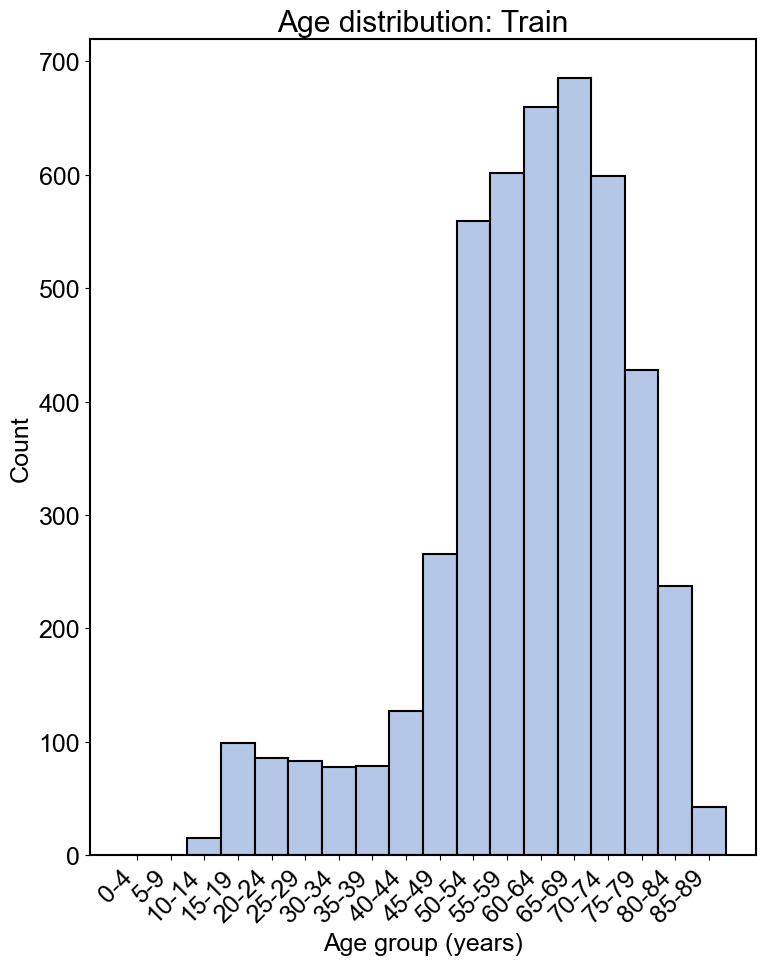

Train plot saved to: ./age_distribution_five\age_distribution_Train.svg


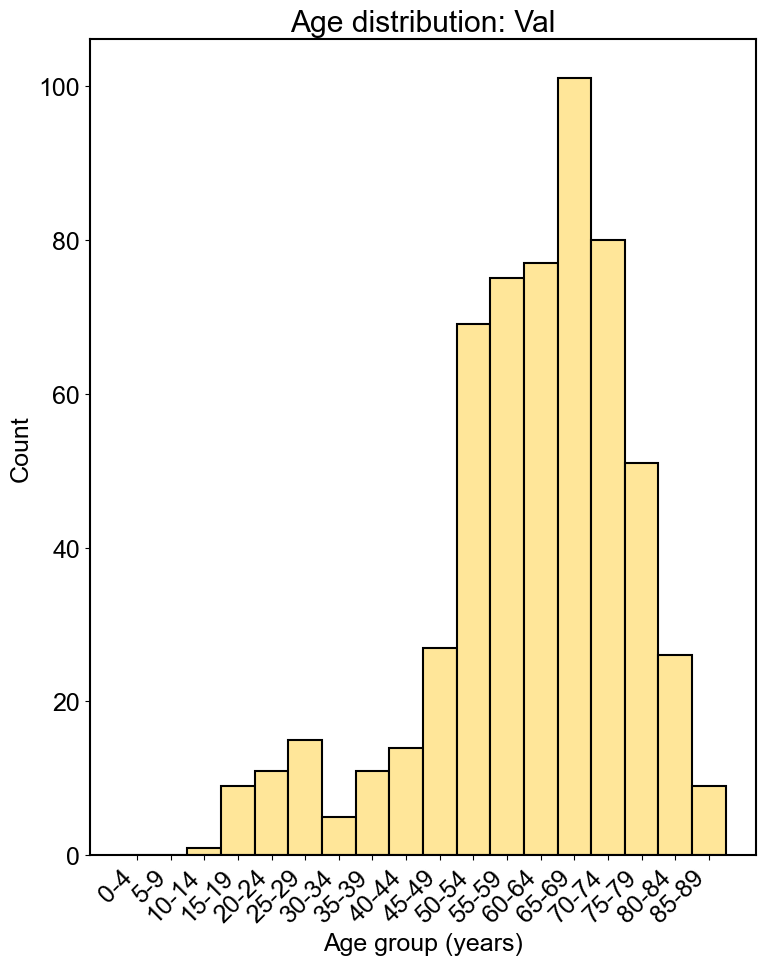

Val plot saved to: ./age_distribution_five\age_distribution_Val.svg


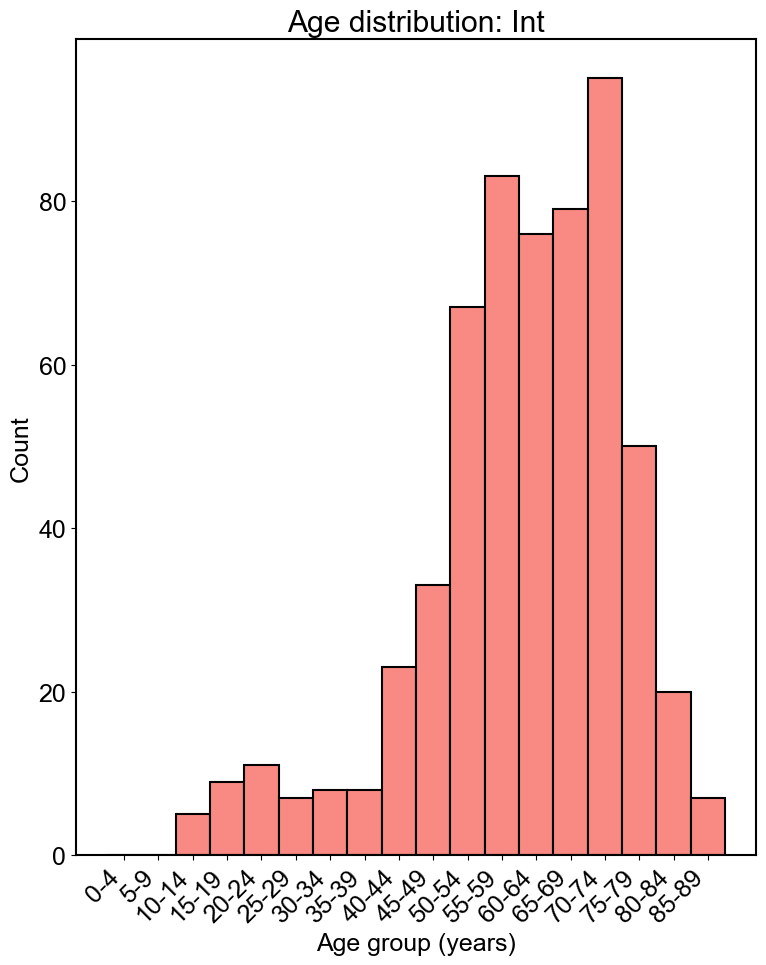

Int plot saved to: ./age_distribution_five\age_distribution_Int.svg


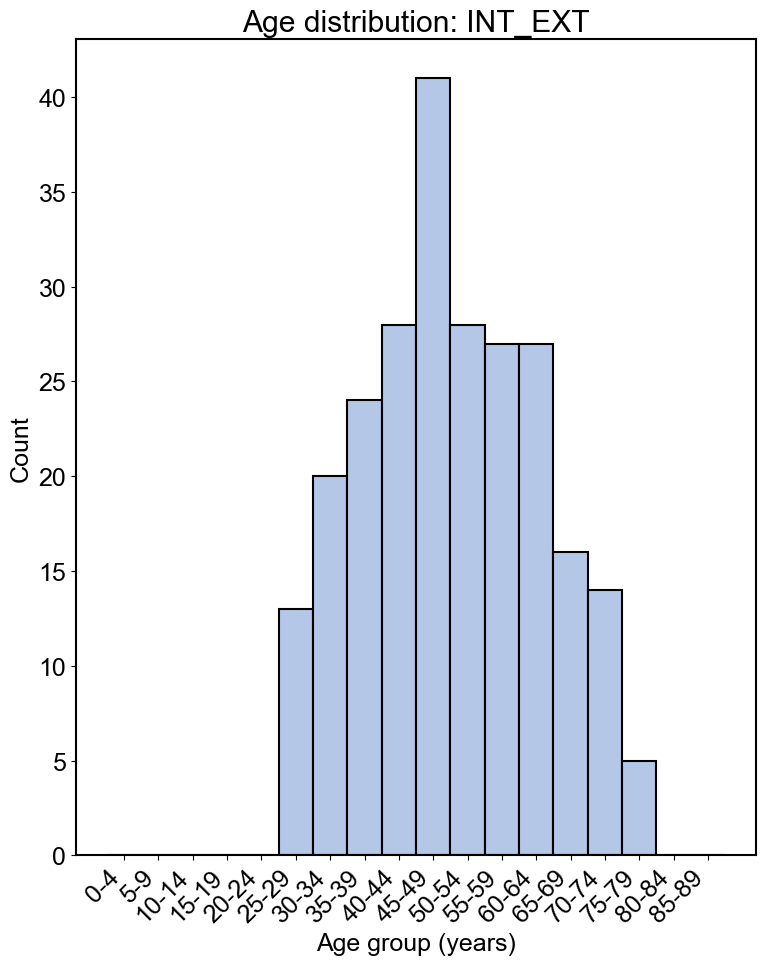

INT_EXT plot saved to: ./age_distribution_five\age_distribution_INT_EXT.svg


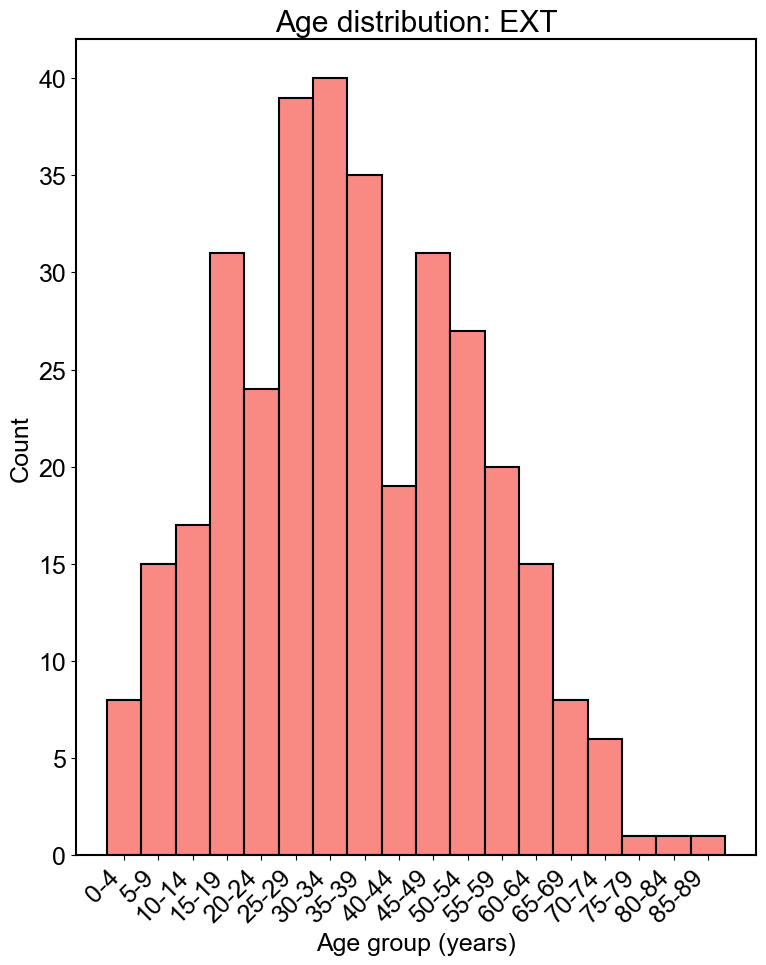

EXT plot saved to: ./age_distribution_five\age_distribution_EXT.svg


In [9]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# =========================
# 1) Healthy samples
# =========================
dat_healty = dat[dat["DIS_HEA"] == "HEA"].copy()
dat_healty["Batch"] = dat_healty["Batch"].astype(str).str.strip()


# =========================
# 2) External, internal-external, and DEF-external datasets
# =========================
EXTERNAL_BATCHES = [
    "ETES1(Influenza1)",
    "ETES2(Influenza2)",
    "ETES3(Influenza3)",
    "ETES4(Major depressive Disease samplesorder1)",
    "ETES5(Major depressive Disease samplesorder2)",
    "ETES6(Covid-19-1)",
    "ETES7(Covid-19-2)",
    "ETES8(Covid-19-3)",
    "ETES9(Covid-19-4)",
    "ES3(LongCovid19)",
]

DEF_EXTERNAL_BATCHES = [
    "ES1(Sepsis)",
    "ES2(Weight loss)",
    "ES3(LongCovid19)",
    "ES4(Pre-post Covid19)",
]

INT_EXT_BATCH = "ETS1"

# DEF-external has the highest priority:
# these samples are extracted first and do not participate in any split.
def_external_mask = dat_healty["Batch"].isin(DEF_EXTERNAL_BATCHES)

# EXT excludes all DEF-external samples, including overlapping Batch names.
ext_mask = (
    ~def_external_mask
    & dat_healty["Batch"].isin(EXTERNAL_BATCHES)
)

# INT_EXT also excludes DEF-external and EXT samples.
int_ext_mask = (
    ~def_external_mask
    & ~ext_mask
    & dat_healty["Batch"].eq(INT_EXT_BATCH)
)

def_external_df = dat_healty[def_external_mask].copy()
test_df = dat_healty[ext_mask].copy()
int_ext_df = dat_healty[int_ext_mask].copy()

train_pool_df = dat_healty[
    ~def_external_mask
    & ~ext_mask
    & ~int_ext_mask
].copy()

print("DEF external samples:", len(def_external_df))
print("External samples:", len(test_df))
print("Internal-external samples:", len(int_ext_df))
print("Training pool samples:", len(train_pool_df))


# =========================
# 3) Select features
# =========================
drop_cols = ["Sample", "AGE", "Batch", "DIS_HEA"]
cols = dat_healty.columns

candidates = (
    [c for c in cols if c.startswith("imm__")]
    + [c for c in cols if c.startswith("g__")]
    + [c for c in cols if c.startswith("ssgsea__")]
)

if "Male" in cols:
    candidates.append("Male")

feature_cols = sorted(
    set(c for c in candidates if c not in drop_cols)
)


# =========================
# 4) Prepare datasets
# =========================
X_all = train_pool_df[feature_cols].copy()
y_all = train_pool_df["AGE"].astype(float).values

X_ext_raw = test_df[feature_cols].copy()
y_ext = test_df["AGE"].astype(float).values

X_int_ext_raw = int_ext_df[feature_cols].copy()
y_int_ext = int_ext_df["AGE"].astype(float).values


# =========================
# 5) Split functions
# =========================
def collapse_rare_strata(strata, batches, min_count=2):
    strata = strata.astype(str).copy()
    batches = batches.astype(str).copy()

    rare = strata.value_counts()[lambda x: x < min_count].index
    rare_mask = strata.isin(rare)
    strata.loc[rare_mask] = batches.loc[rare_mask]

    rare = strata.value_counts()[lambda x: x < min_count].index
    strata.loc[strata.isin(rare)] = "OTHER"

    return strata


def build_strata(dataframe, n_bins):
    meta = dataframe[["Batch", "AGE"]].copy()
    meta["Batch"] = meta["Batch"].astype(str).str.strip()

    bins = min(n_bins, max(2, meta.shape[0] // 10))

    meta["AGE_bin"] = pd.qcut(
        meta["AGE"],
        q=bins,
        duplicates="drop",
    ).astype(str)

    meta["strata"] = meta["Batch"] + "__" + meta["AGE_bin"]
    meta["strata"] = collapse_rare_strata(
        meta["strata"],
        meta["Batch"],
        min_count=2,
    )

    return meta["strata"]


def split_with_optional_stratify(X, y, test_size, strata):
    stratify = (
        strata.values
        if not strata.empty and strata.value_counts().min() >= 2
        else None
    )

    return train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=SEED,
        stratify=stratify,
    )


# =========================
# 6) Train, validation, and internal test split
# =========================
split_strata = build_strata(
    train_pool_df.loc[X_all.index],
    n_bins=4,
)

X_train_raw, X_temp_raw, y_train, y_temp = split_with_optional_stratify(
    X_all,
    y_all,
    test_size=0.2,
    strata=split_strata,
)

temp_strata = build_strata(
    train_pool_df.loc[X_temp_raw.index],
    n_bins=4,
)

X_val_raw, X_int_raw, y_val, y_int = split_with_optional_stratify(
    X_temp_raw,
    y_temp,
    test_size=0.5,
    strata=temp_strata,
)


# =========================
# 7) Preprocess features
# =========================
cat_cols = [
    c
    for c in feature_cols
    if X_train_raw[c].dtype == "object"
    or str(X_train_raw[c].dtype) == "category"
]

num_cols = [c for c in feature_cols if c not in cat_cols]

transformers = []

if num_cols:
    transformers.append(
        (
            "num",
            Pipeline(
                [
                    ("imp", SimpleImputer(strategy="median")),
                    ("sc", StandardScaler()),
                ]
            ),
            num_cols,
        )
    )

if cat_cols:
    transformers.append(
        (
            "cat",
            Pipeline(
                [
                    ("imp", SimpleImputer(strategy="most_frequent")),
                    ("oh", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            cat_cols,
        )
    )

preprocess = ColumnTransformer(
    transformers=transformers,
)

X_train = preprocess.fit_transform(X_train_raw)
X_val = preprocess.transform(X_val_raw)
X_int = preprocess.transform(X_int_raw)
X_int_ext = preprocess.transform(X_int_ext_raw)
X_ext = preprocess.transform(X_ext_raw)


# =========================
# 8) Age distribution settings
# =========================
FONT_SIZE = 18
SAVE_DIR = "./age_distribution_five"

os.makedirs(SAVE_DIR, exist_ok=True)

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = FONT_SIZE


# =========================
# 9) Age data
# =========================
age_dict = {
    "Train": np.asarray(y_train, dtype=float),
    "Val": np.asarray(y_val, dtype=float),
    "Int": np.asarray(y_int, dtype=float),
    "INT_EXT": np.asarray(y_int_ext, dtype=float),
    "EXT": np.asarray(y_ext, dtype=float),
}


# =========================
# 10) Age bins
# =========================
all_ages = np.concatenate(list(age_dict.values()))
all_ages = all_ages[~np.isnan(all_ages)]

age_min = np.floor(all_ages.min() / 5) * 5
age_max = np.ceil(all_ages.max() / 5) * 5

bins = np.arange(age_min, age_max + 5, 5)

bin_labels = [
    "{}-{}".format(int(bins[i]), int(bins[i + 1] - 1))
    for i in range(len(bins) - 1)
]


# =========================
# 11) Plot colors
# =========================
colors = {
    "Train": "#B4C7E7",
    "Val": "#FFE699",
    "Int": "#F98A83",
    "INT_EXT": "#B4C7E7",
    "EXT": "#F98A83",
}


# =========================
# 12) Plot each dataset
# =========================
x_positions = np.arange(len(bin_labels))

for name, ages in age_dict.items():
    valid_ages = ages[~np.isnan(ages)]

    counts = (
        pd.cut(
            valid_ages,
            bins=bins,
            right=False,
            labels=bin_labels,
            include_lowest=True,
        )
        .value_counts()
        .sort_index()
    )

    fig, ax = plt.subplots(figsize=(8, 10))

    ax.bar(
        x=x_positions,
        height=counts.values,
        width=1.0,
        color=colors[name],
        edgecolor="black",
        linewidth=1.5,
    )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(
        bin_labels,
        rotation=45,
        ha="right",
    )

    ax.set_xlabel("Age group (years)")
    ax.set_ylabel("Count")
    ax.set_title("Age distribution: {}".format(name))
    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1.5)

    fig.tight_layout()

    svg_path = os.path.join(
        SAVE_DIR,
        "age_distribution_{}.svg".format(name),
    )

    fig.savefig(
        svg_path,
        format="svg",
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    print("{} plot saved to: {}".format(name, svg_path))


In [11]:
# ==============================================================
# 10-fold training + artifact saving for downstream ensemble
# ==============================================================

import os
import json
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.base import clone
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from scipy.stats import spearmanr


# =========================
# 0) Global settings
# =========================
SEED = 42
N_SPLITS = 10
SAVE_DIR = "./cv_10fold_artifacts"
os.makedirs(SAVE_DIR, exist_ok=True)

np.random.seed(SEED)
try:
    tf.random.set_seed(SEED)
except Exception:
    pass


# =========================
# 1) Helper functions
# =========================
def _to_dense_float32(x):
    """Convert sparse/dense matrix to dense float32 ndarray."""
    if hasattr(x, "toarray"):
        x = x.toarray()
    x = np.asarray(x)
    if x.dtype != np.float32:
        x = x.astype(np.float32, copy=False)
    return x


def _safe_spearman(y_true, y_pred):
    if len(y_true) == 0:
        return float("nan")
    rho = spearmanr(y_true, y_pred)[0]
    try:
        return float(rho) if np.isfinite(rho) else float("nan")
    except Exception:
        return float("nan")


def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    if len(y_true) == 0:
        return {
            "RMSE": float("nan"),
            "MAE": float("nan"),
            "R2": float("nan"),
            "Spearman": float("nan")
        }

    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "R2": float(r2_score(y_true, y_pred)),
        "Spearman": _safe_spearman(y_true, y_pred)
    }


def summarize_fold_metrics(fold_metrics_list, split="Val"):
    """Average metrics across folds."""
    keys = ["RMSE", "MAE", "R2", "Spearman"]
    out = {}
    for k in keys:
        vals = [fm[split][k] for fm in fold_metrics_list]
        out[k] = float(np.nanmean(vals))
    return out


def safe_predict_sklearn(model, X, need_dense=False):
    if X.shape[0] == 0:
        return np.array([], dtype=float)
    if need_dense:
        X = _to_dense_float32(X)
    pred = model.predict(X)
    return np.asarray(pred, dtype=float).ravel()


def build_dnn(input_dim):
    model = tf.keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1)
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="mse"
    )
    return model


def predict_dnn(model, X):
    if X.shape[0] == 0:
        return np.array([], dtype=float)
    X = _to_dense_float32(X)
    pred = model.predict(X, verbose=0).ravel()
    return np.asarray(pred, dtype=float)


# =========================
# 2) Models
# =========================
ml_models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01, max_iter=20000, random_state=SEED),
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=20000, random_state=SEED),
    "DecisionTree": DecisionTreeRegressor(random_state=SEED),
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        random_state=SEED,
        n_jobs=-1
    ),
    "SVR": SVR(kernel="rbf", C=10, gamma="scale"),
    "XGBoost": XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=SEED,
        n_jobs=-1
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=500,
        learning_rate=0.03,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=SEED,
        n_jobs=-1
    ),
    "CatBoost": CatBoostRegressor(
        iterations=500,
        depth=6,
        learning_rate=0.03,
        loss_function="RMSE",
        verbose=False,
        random_seed=SEED
    ),
    "DNN": None
}


# =========================
# 3) CV containers
# =========================
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

cv_artifacts = {}
summary_rows = []


# =========================
# 4) 10-fold training
# =========================
print("Shapes:")
print("X_train   :", X_train.shape, "y_train   :", len(y_train))
print("X_val     :", X_val.shape, "y_val     :", len(y_val))
print("X_int     :", X_int.shape, "y_int     :", len(y_int))
print("X_int_ext :", X_int_ext.shape, "y_int_ext :", len(y_int_ext))
print("X_ext     :", X_ext.shape, "y_ext     :", len(y_ext))


for model_name, base_model in ml_models.items():
    print(f"\n{'=' * 70}")
    print(f"Training model: {model_name}")
    print(f"{'=' * 70}")

    # OOF prediction on X_train
    oof_pred = np.full(len(y_train), np.nan, dtype=float)

    # per-fold prediction holders for downstream ensemble
    fold_pred_int_ext = []
    fold_pred_ext = []
    fold_pred_int = []
    fold_pred_val_fixed = []   # fixed validation set outside CV
    fold_models = []
    fold_metrics = []

    best_fold_idx = None
    best_fold_score = -np.inf

    for fold_idx, (tr_idx, va_idx) in enumerate(kf.split(X_train), start=1):
        print(f"  Fold {fold_idx}/{N_SPLITS}")

        X_tr = X_train[tr_idx]
        X_va = X_train[va_idx]
        y_tr = np.asarray(y_train)[tr_idx]
        y_va = np.asarray(y_train)[va_idx]

        # -------------------------
        # Train model
        # -------------------------
        if model_name == "DNN":
            X_tr_dense = _to_dense_float32(X_tr)
            X_va_dense = _to_dense_float32(X_va)

            model = build_dnn(X_tr_dense.shape[1])
            es = EarlyStopping(
                monitor="val_loss",
                patience=20,
                restore_best_weights=True
            )

            model.fit(
                X_tr_dense, y_tr,
                validation_data=(X_va_dense, y_va),
                epochs=300,
                batch_size=64,
                verbose=0,
                callbacks=[es]
            )

            pred_tr = predict_dnn(model, X_tr)
            pred_va = predict_dnn(model, X_va)

            pred_int = predict_dnn(model, X_int)
            pred_val_fixed = predict_dnn(model, X_val)
            pred_int_ext = predict_dnn(model, X_int_ext)
            pred_ext = predict_dnn(model, X_ext)

        else:
            model = clone(base_model)
            need_dense = (model_name == "SVR")

            if need_dense:
                X_tr_fit = _to_dense_float32(X_tr)
                X_va_fit = _to_dense_float32(X_va)
            else:
                X_tr_fit = X_tr
                X_va_fit = X_va

            model.fit(X_tr_fit, y_tr)

            pred_tr = safe_predict_sklearn(model, X_tr, need_dense=need_dense)
            pred_va = safe_predict_sklearn(model, X_va, need_dense=need_dense)

            pred_int = safe_predict_sklearn(model, X_int, need_dense=need_dense)
            pred_val_fixed = safe_predict_sklearn(model, X_val, need_dense=need_dense)
            pred_int_ext = safe_predict_sklearn(model, X_int_ext, need_dense=need_dense)
            pred_ext = safe_predict_sklearn(model, X_ext, need_dense=need_dense)

        # -------------------------
        # Save OOF and fold outputs
        # -------------------------
        oof_pred[va_idx] = pred_va
        fold_pred_int.append(pred_int)
        fold_pred_val_fixed.append(pred_val_fixed)
        fold_pred_int_ext.append(pred_int_ext)
        fold_pred_ext.append(pred_ext)
        fold_models.append(model)

        # -------------------------
        # Metrics
        # -------------------------
        this_fold_metrics = {
            "Fold": fold_idx,
            "Train": compute_metrics(y_tr, pred_tr),
            "Val": compute_metrics(y_va, pred_va),
            "Fixed_VAL": compute_metrics(y_val, pred_val_fixed),
            "INT": compute_metrics(y_int, pred_int),
            "INT_EXT": compute_metrics(y_int_ext, pred_int_ext),
            "EXT": compute_metrics(y_ext, pred_ext)
        }
        fold_metrics.append(this_fold_metrics)

        print(
            f"    Train R2={this_fold_metrics['Train']['R2']:.4f} | "
            f"CV-Val R2={this_fold_metrics['Val']['R2']:.4f} | "
            f"AGE2 R2={this_fold_metrics['INT_EXT']['R2']:.4f} | "
            f"EXT R2={this_fold_metrics['EXT']['R2']:.4f}"
        )

        # best fold judged by CV validation R2
        if this_fold_metrics["Val"]["R2"] > best_fold_score:
            best_fold_score = this_fold_metrics["Val"]["R2"]
            best_fold_idx = fold_idx

    # -------------------------
    # Aggregate
    # -------------------------
    mean_train_metrics = summarize_fold_metrics(fold_metrics, split="Train")
    mean_val_metrics = summarize_fold_metrics(fold_metrics, split="Val")
    mean_fixed_val_metrics = summarize_fold_metrics(fold_metrics, split="Fixed_VAL")
    mean_int_metrics = summarize_fold_metrics(fold_metrics, split="INT")
    mean_int_ext_metrics = summarize_fold_metrics(fold_metrics, split="INT_EXT")
    mean_ext_metrics = summarize_fold_metrics(fold_metrics, split="EXT")

    best_fold_metrics = fold_metrics[best_fold_idx - 1]

    # mean prediction across folds, useful for later ensemble or reporting
    mean_pred_int = np.mean(np.vstack(fold_pred_int), axis=0) if len(y_int) > 0 else np.array([])
    mean_pred_val_fixed = np.mean(np.vstack(fold_pred_val_fixed), axis=0) if len(y_val) > 0 else np.array([])
    mean_pred_int_ext = np.mean(np.vstack(fold_pred_int_ext), axis=0) if len(y_int_ext) > 0 else np.array([])
    mean_pred_ext = np.mean(np.vstack(fold_pred_ext), axis=0) if len(y_ext) > 0 else np.array([])

    cv_artifacts[model_name] = {
        "model_name": model_name,
        "n_splits": N_SPLITS,

        # trained fold models
        "fold_models": fold_models,

        # fold-wise metrics
        "fold_metrics": fold_metrics,

        # averages
        "mean_train_metrics": mean_train_metrics,
        "mean_val_metrics": mean_val_metrics,
        "mean_fixed_val_metrics": mean_fixed_val_metrics,
        "mean_int_metrics": mean_int_metrics,
        "mean_int_ext_metrics": mean_int_ext_metrics,
        "mean_ext_metrics": mean_ext_metrics,

        # best fold
        "best_fold": best_fold_idx,
        "best_fold_metrics": best_fold_metrics,

        # OOF on X_train for downstream stacking
        "oof_pred_train": oof_pred,

        # per-fold predictions for downstream ensemble
        "fold_pred_val_fixed": fold_pred_val_fixed,
        "fold_pred_int": fold_pred_int,
        "fold_pred_int_ext": fold_pred_int_ext,
        "fold_pred_ext": fold_pred_ext,

        # fold-mean predictions
        "mean_pred_val_fixed": mean_pred_val_fixed,
        "mean_pred_int": mean_pred_int,
        "mean_pred_int_ext": mean_pred_int_ext,
        "mean_pred_ext": mean_pred_ext
    }

    summary_rows.append({
        "Model": model_name,
        "Best_Fold": best_fold_idx,

        "CV_Train_RMSE_Mean": mean_train_metrics["RMSE"],
        "CV_Train_MAE_Mean": mean_train_metrics["MAE"],
        "CV_Train_R2_Mean": mean_train_metrics["R2"],
        "CV_Train_Spearman_Mean": mean_train_metrics["Spearman"],

        "CV_Val_RMSE_Mean": mean_val_metrics["RMSE"],
        "CV_Val_MAE_Mean": mean_val_metrics["MAE"],
        "CV_Val_R2_Mean": mean_val_metrics["R2"],
        "CV_Val_Spearman_Mean": mean_val_metrics["Spearman"],

        "AGE2_RMSE_Mean": mean_int_ext_metrics["RMSE"],
        "AGE2_MAE_Mean": mean_int_ext_metrics["MAE"],
        "AGE2_R2_Mean": mean_int_ext_metrics["R2"],
        "AGE2_Spearman_Mean": mean_int_ext_metrics["Spearman"],

        "EXT_RMSE_Mean": mean_ext_metrics["RMSE"],
        "EXT_MAE_Mean": mean_ext_metrics["MAE"],
        "EXT_R2_Mean": mean_ext_metrics["R2"],
        "EXT_Spearman_Mean": mean_ext_metrics["Spearman"],

        "BestFold_CV_Val_R2": best_fold_metrics["Val"]["R2"],
        "BestFold_AGE2_R2": best_fold_metrics["INT_EXT"]["R2"],
        "BestFold_EXT_R2": best_fold_metrics["EXT"]["R2"],
    })


# =========================
# 5) Summary tables
# =========================
summary_df = pd.DataFrame(summary_rows).sort_values(
    by="CV_Val_R2_Mean",
    ascending=False
).reset_index(drop=True)

print("\n===== 10-fold summary =====")
print(summary_df)

# 每个模型每个fold表现展开成表
fold_rows = []
for model_name, res in cv_artifacts.items():
    for fm in res["fold_metrics"]:
        row = {"Model": model_name, "Fold": fm["Fold"]}
        for split_name in ["Train", "Val", "Fixed_VAL", "INT", "INT_EXT", "EXT"]:
            for metric_name, metric_val in fm[split_name].items():
                row[f"{split_name}_{metric_name}"] = metric_val
        fold_rows.append(row)

fold_df = pd.DataFrame(fold_rows)
print("\n===== Fold-wise performance =====")
print(fold_df.head())


# =========================
# 6) Save results for downstream ensemble
# =========================
summary_df.to_csv(os.path.join(SAVE_DIR, "cv_summary.csv"), index=False)
fold_df.to_csv(os.path.join(SAVE_DIR, "cv_fold_metrics.csv"), index=False)

light_artifacts = {}
for model_name, res in cv_artifacts.items():
    light_artifacts[model_name] = {
        "model_name": res["model_name"],
        "n_splits": res["n_splits"],
        "best_fold": res["best_fold"],
        "mean_train_metrics": res["mean_train_metrics"],
        "mean_val_metrics": res["mean_val_metrics"],
        "mean_fixed_val_metrics": res["mean_fixed_val_metrics"],
        "mean_int_metrics": res["mean_int_metrics"],
        "mean_int_ext_metrics": res["mean_int_ext_metrics"],
        "mean_ext_metrics": res["mean_ext_metrics"],
        "best_fold_metrics": res["best_fold_metrics"],
        "oof_pred_train": res["oof_pred_train"],
        "fold_pred_val_fixed": res["fold_pred_val_fixed"],
        "fold_pred_int": res["fold_pred_int"],
        "fold_pred_int_ext": res["fold_pred_int_ext"],
        "fold_pred_ext": res["fold_pred_ext"],
        "mean_pred_val_fixed": res["mean_pred_val_fixed"],
        "mean_pred_int": res["mean_pred_int"],
        "mean_pred_int_ext": res["mean_pred_int_ext"],
        "mean_pred_ext": res["mean_pred_ext"]
    }

with open(os.path.join(SAVE_DIR, "cv_artifacts.pkl"), "wb") as f:
    pickle.dump(light_artifacts, f)

with open(os.path.join(SAVE_DIR, "cv_summary.json"), "w", encoding="utf-8") as f:
    json.dump(summary_rows, f, ensure_ascii=False, indent=2)

print(f"\nAll CV artifacts are saved to: {SAVE_DIR}")

Shapes:
X_train   : (4646, 422) y_train   : 4646
X_val     : (581, 422) y_val     : 581
X_int     : (581, 422) y_int     : 581
X_int_ext : (243, 422) y_int_ext : 243
X_ext     : (339, 422) y_ext     : 339

Training model: LinearRegression
  Fold 1/10
    Train R2=0.8760 | CV-Val R2=0.7587 | AGE2 R2=0.7698 | EXT R2=-2.7423
  Fold 2/10
    Train R2=0.8782 | CV-Val R2=0.7064 | AGE2 R2=0.7810 | EXT R2=-2.9493
  Fold 3/10
    Train R2=0.8728 | CV-Val R2=0.8198 | AGE2 R2=0.7724 | EXT R2=-2.8718
  Fold 4/10
    Train R2=0.8727 | CV-Val R2=0.8103 | AGE2 R2=0.7837 | EXT R2=-2.5251
  Fold 5/10
    Train R2=0.8768 | CV-Val R2=0.7413 | AGE2 R2=0.7965 | EXT R2=-3.1125
  Fold 6/10
    Train R2=0.8745 | CV-Val R2=0.7885 | AGE2 R2=0.7849 | EXT R2=-2.8002
  Fold 7/10
    Train R2=0.8736 | CV-Val R2=0.8178 | AGE2 R2=0.7784 | EXT R2=-3.0220
  Fold 8/10
    Train R2=0.8723 | CV-Val R2=0.7626 | AGE2 R2=0.7825 | EXT R2=-2.2763
  Fold 9/10
    Train R2=0.8711 | CV-Val R2=0.8361 | AGE2 R2=0.7858 | EXT R2=-2.6

C:\Users\23202\anaconda3\envs\DL\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.262e+03, tolerance: 9.322e+01
  model = cd_fast.enet_coordinate_descent(


    Train R2=0.8711 | CV-Val R2=0.7642 | AGE2 R2=0.7517 | EXT R2=-1.8250
  Fold 2/10


C:\Users\23202\anaconda3\envs\DL\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.813e+03, tolerance: 9.525e+01
  model = cd_fast.enet_coordinate_descent(


    Train R2=0.8733 | CV-Val R2=0.7531 | AGE2 R2=0.7635 | EXT R2=-2.0541
  Fold 3/10


...

    Train R2=0.9982 | CV-Val R2=0.9620 | AGE2 R2=0.1533 | EXT R2=-0.4338
  Fold 9/10
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.022939 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 107081
[LightGBM] [Info] Number of data points in the train set: 4182, number of used features: 422
[LightGBM] [Info] Start training from score 60.005978


C:\Users\23202\anaconda3\envs\DL\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\23202\anaconda3\envs\DL\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\23202\anaconda3\envs\DL\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\23202\anaconda3\envs\DL\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\23202\anaconda3\envs\DL\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


    Train R2=0.9982 | CV-Val R2=0.9590 | AGE2 R2=0.1611 | EXT R2=-0.4380
  Fold 10/10
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.027062 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 107085
[LightGBM] [Info] Number of data points in the train set: 4182, number of used features: 422
[LightGBM] [Info] Start training from score 59.998087


C:\Users\23202\anaconda3\envs\DL\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\23202\anaconda3\envs\DL\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\23202\anaconda3\envs\DL\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\23202\anaconda3\envs\DL\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\23202\anaconda3\envs\DL\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


    Train R2=0.9983 | CV-Val R2=0.9529 | AGE2 R2=0.2009 | EXT R2=-0.4931

Training model: CatBoost
  Fold 1/10
    Train R2=0.9746 | CV-Val R2=0.9330 | AGE2 R2=0.3573 | EXT R2=-0.5815
  Fold 2/10
    Train R2=0.9748 | CV-Val R2=0.9231 | AGE2 R2=0.3478 | EXT R2=-0.5561
  Fold 3/10
    Train R2=0.9750 | CV-Val R2=0.9287 | AGE2 R2=0.3653 | EXT R2=-0.5457
  Fold 4/10
    Train R2=0.9743 | CV-Val R2=0.9523 | AGE2 R2=0.3625 | EXT R2=-0.4813
  Fold 5/10
    Train R2=0.9743 | CV-Val R2=0.9233 | AGE2 R2=0.3394 | EXT R2=-0.5614
  Fold 6/10
    Train R2=0.9738 | CV-Val R2=0.9376 | AGE2 R2=0.3483 | EXT R2=-0.5262
  Fold 7/10
    Train R2=0.9745 | CV-Val R2=0.9322 | AGE2 R2=0.3693 | EXT R2=-0.5425
  Fold 8/10
    Train R2=0.9746 | CV-Val R2=0.9473 | AGE2 R2=0.3573 | EXT R2=-0.5437
  Fold 9/10
    Train R2=0.9736 | CV-Val R2=0.9452 | AGE2 R2=0.3378 | EXT R2=-0.5805
  Fold 10/10
    Train R2=0.9743 | CV-Val R2=0.9207 | AGE2 R2=0.3398 | EXT R2=-0.5667

Training model: DNN
  Fold 1/10
    Train R2=0.95

In [107]:
# ==============================================================
# Weighted ensemble optimized on INT_EXT (AGE2)
# Compatible with leak-free cv_artifacts
# ==============================================================

import numpy as np
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import spearmanr


# -------------------
# 0) Optional settings
# -------------------

metric_to_optimize = "hybrid"

alpha = 0.5   # loss = alpha * normalized_MAE + (1-alpha) * normalized_RMSE

# -------------------
# 1) Helper functions
# -------------------
def _safe_spearman(y, pred):
    if len(y) == 0:
        return float("nan")
    rho = spearmanr(y, pred)[0]
    try:
        return float(rho) if np.isfinite(rho) else float("nan")
    except Exception:
        return float("nan")


def compute_metrics(y, pred):
    y = np.asarray(y, dtype=float)
    pred = np.asarray(pred, dtype=float)

    if len(y) == 0:
        return {
            "RMSE": float("nan"),
            "MAE": float("nan"),
            "R2": float("nan"),
            "Spearman": float("nan")
        }

    return {
        "RMSE": float(np.sqrt(mean_squared_error(y, pred))),
        "MAE": float(mean_absolute_error(y, pred)),
        "R2": float(r2_score(y, pred)),
        "Spearman": _safe_spearman(y, pred)
    }


def _objective_metric(y_true, y_pred, metric="hybrid", mae_scale=1.0, rmse_scale=1.0, alpha=0.5):
    """
    Smaller is better
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))

    if not np.isfinite(mae_scale) or mae_scale <= 0:
        mae_scale = 1.0
    if not np.isfinite(rmse_scale) or rmse_scale <= 0:
        rmse_scale = 1.0

    metric = str(metric).lower()

    if metric == "rmse":
        return rmse
    elif metric == "mae":
        return mae
    elif metric == "hybrid":
        return alpha * (mae / mae_scale) + (1.0 - alpha) * (rmse / rmse_scale)
    else:
        raise ValueError(f"Unsupported metric: {metric}")


def build_pred_matrix(cv_artifacts, model_names, key):
    """
    key examples:
    - 'oof_pred_train'
    - 'mean_pred_val_fixed'
    - 'mean_pred_int'
    - 'mean_pred_int_ext'
    - 'mean_pred_ext'
    """
    mats = []
    for m in model_names:
        if m not in cv_artifacts:
            raise KeyError(f"Model '{m}' not found in cv_artifacts")

        pred = np.asarray(cv_artifacts[m][key], dtype=float).ravel()
        mats.append(pred)

    if len(mats) == 0:
        raise ValueError("No model predictions available for building prediction matrix")

    lengths = [len(x) for x in mats]
    if len(set(lengths)) != 1:
        raise ValueError(f"Inconsistent prediction lengths in {key}: {lengths}")

    return np.column_stack(mats)


def ensemble_predict(pred_matrix, weights):
    pred_matrix = np.asarray(pred_matrix, dtype=float)
    weights = np.asarray(weights, dtype=float).ravel()
    return pred_matrix @ weights


# -------------------
# 2) Select models
# -------------------
all_model_names = list(cv_artifacts.keys())
model_names = [m for m in all_model_names if m not in exclude_models]

if len(model_names) == 0:
    raise ValueError("No base models left after exclusion.")

print("Models used for ensemble:")
for m in model_names:
    print(" -", m)


# -------------------
# 3) Build prediction matrices from cv_artifacts
# -------------------
# Train: use strict OOF predictions
pred_matrix_train = build_pred_matrix(cv_artifacts, model_names, "oof_pred_train")

# Other datasets: use mean prediction across folds
pred_matrix_val = build_pred_matrix(cv_artifacts, model_names, "mean_pred_val_fixed")
pred_matrix_int = build_pred_matrix(cv_artifacts, model_names, "mean_pred_int")
pred_matrix_int_ext = build_pred_matrix(cv_artifacts, model_names, "mean_pred_int_ext")
pred_matrix_ext = build_pred_matrix(cv_artifacts, model_names, "mean_pred_ext")

# Ground truth
y_train_true = np.asarray(y_train, dtype=float)
y_val_true = np.asarray(y_val, dtype=float)
y_int_true = np.asarray(y_int, dtype=float)
y_int_ext_true = np.asarray(y_int_ext, dtype=float)
y_ext_true = np.asarray(y_ext, dtype=float)

print("\nPrediction matrix shapes:")
print("Train   :", pred_matrix_train.shape)
print("Val     :", pred_matrix_val.shape)
print("Int     :", pred_matrix_int.shape)
print("Int_Ext :", pred_matrix_int_ext.shape)
print("Ext     :", pred_matrix_ext.shape)


# -------------------
# 4) Compute normalization scales on INT_EXT
# -------------------
candidate_maes = []
candidate_rmses = []

for i in range(pred_matrix_int_ext.shape[1]):
    pred_i = pred_matrix_int_ext[:, i]
    try:
        candidate_maes.append(mean_absolute_error(y_int_ext_true, pred_i))
        candidate_rmses.append(np.sqrt(mean_squared_error(y_int_ext_true, pred_i)))
    except Exception:
        pass

mae_scale = np.nanmean(candidate_maes) if len(candidate_maes) > 0 else 1.0
rmse_scale = np.nanmean(candidate_rmses) if len(candidate_rmses) > 0 else 1.0

if not np.isfinite(mae_scale) or mae_scale <= 0:
    mae_scale = 1.0
if not np.isfinite(rmse_scale) or rmse_scale <= 0:
    rmse_scale = 1.0

print(f"\nMAE scale  for normalization: {mae_scale:.6f}")
print(f"RMSE scale for normalization: {rmse_scale:.6f}")
print(f"Optimization metric: {metric_to_optimize}, alpha={alpha:.2f}")


# -------------------
# 5) Define optimization objective on INT_EXT
# -------------------
def loss_fn(weights):
    weights = np.asarray(weights, dtype=float)
    y_pred = pred_matrix_int_ext @ weights
    return _objective_metric(
        y_int_ext_true,
        y_pred,
        metric=metric_to_optimize,
        mae_scale=mae_scale,
        rmse_scale=rmse_scale,
        alpha=alpha
    )


# -------------------
# 6) Constraints: weights sum to 1, weights >= 0
# -------------------
M = pred_matrix_int_ext.shape[1]
init_w = np.ones(M, dtype=float) / M
bounds = [(0.0, 1.0)] * M
constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}]


# -------------------
# 7) Optimize weights on INT_EXT
# -------------------
res = minimize(
    loss_fn,
    init_w,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

if res.success and (res.x is not None) and np.isfinite(res.x).all():
    best_w = np.asarray(res.x, dtype=float)
    if best_w.sum() > 0:
        best_w = best_w / best_w.sum()
    else:
        best_w = np.ones(M, dtype=float) / M
else:
    print("WARNING: optimization failed, using uniform weights")
    best_w = np.ones(M, dtype=float) / M

best_weights = dict(zip(model_names, best_w))

print("\n===== Optimized Weights =====")
for m, w in sorted(best_weights.items(), key=lambda x: x[1], reverse=True):
    print(f"{m}: {w:.6f}")


# -------------------
# 8) Apply ensemble to all datasets
# -------------------
ensemble_predictions = {
    "Train": ensemble_predict(pred_matrix_train, best_w),
    "Val": ensemble_predict(pred_matrix_val, best_w),
    "Int": ensemble_predict(pred_matrix_int, best_w),
    "Int_Ext": ensemble_predict(pred_matrix_int_ext, best_w),
    "Ext": ensemble_predict(pred_matrix_ext, best_w),
}


# -------------------
# 9) Metrics for ensemble
# -------------------
train_metrics = compute_metrics(y_train_true, ensemble_predictions["Train"])
val_metrics = compute_metrics(y_val_true, ensemble_predictions["Val"])
int_metrics = compute_metrics(y_int_true, ensemble_predictions["Int"])
int_ext_metrics = compute_metrics(y_int_ext_true, ensemble_predictions["Int_Ext"])
ext_metrics = compute_metrics(y_ext_true, ensemble_predictions["Ext"])


# -------------------
# 10) Print summary
# -------------------
print("\n===== Weighted Ensemble (optimized on INT_EXT / AGE2) =====")
print(f"Optimization metric: {metric_to_optimize}")
print(f"alpha (MAE weight in hybrid): {alpha:.2f}")

print("\nTrain   :", {k: round(v, 4) if np.isfinite(v) else np.nan for k, v in train_metrics.items()})
print("Val     :", {k: round(v, 4) if np.isfinite(v) else np.nan for k, v in val_metrics.items()})
print("Int     :", {k: round(v, 4) if np.isfinite(v) else np.nan for k, v in int_metrics.items()})
print("Int_Ext :", {k: round(v, 4) if np.isfinite(v) else np.nan for k, v in int_ext_metrics.items()})
print("Ext     :", {k: round(v, 4) if np.isfinite(v) else np.nan for k, v in ext_metrics.items()})


# -------------------
# 11) Save results
# -------------------
if "model_results" not in globals():
    model_results = {}

model_results["WeightedEnsemble_IntExt"] = {
    "Optimized_on": "Int_Ext",
    "Metric_used": metric_to_optimize,
    "Alpha_MAE_weight": alpha,
    "MAE_scale": mae_scale,
    "RMSE_scale": rmse_scale,
    "Base_Models": model_names,
    "Weights": best_weights,
    "Weight_Vector": best_w,

    "Train_pred": ensemble_predictions["Train"],
    "Val_pred": ensemble_predictions["Val"],
    "Int_pred": ensemble_predictions["Int"],
    "Int_Ext_pred": ensemble_predictions["Int_Ext"],
    "Ext_pred": ensemble_predictions["Ext"],

    "Train": train_metrics,
    "Val": val_metrics,
    "Int": int_metrics,
    "Int_Ext": int_ext_metrics,
    "Ext": ext_metrics,
}

print("\nWeighted ensemble results saved to model_results['WeightedEnsemble_IntExt']")

Models used for ensemble:
 - LinearRegression
 - Ridge
 - Lasso

Prediction matrix shapes:
Train   : (5400, 3)
Val     : (675, 3)
Int     : (676, 3)
Int_Ext : (243, 3)
Ext     : (517, 3)

MAE scale  for normalization: 6.170677
RMSE scale for normalization: 7.635766
Optimization metric: hybrid, alpha=0.50

===== Optimized Weights =====
Lasso: 1.000000
Ridge: 0.000000
LinearRegression: 0.000000

===== Weighted Ensemble (optimized on INT_EXT / AGE2) =====
Optimization metric: hybrid
alpha (MAE weight in hybrid): 0.50

Train   : {'RMSE': 8.7285, 'MAE': 6.2487, 'R2': 0.8001, 'Spearman': 0.9013}
Val     : {'RMSE': 8.3078, 'MAE': 6.2276, 'R2': 0.813, 'Spearman': 0.9107}
Int     : {'RMSE': 8.8201, 'MAE': 6.4042, 'R2': 0.801, 'Spearman': 0.9096}
Int_Ext : {'RMSE': 7.5666, 'MAE': 6.139, 'R2': 0.6381, 'Spearman': 0.9204}
Ext     : {'RMSE': 18.8297, 'MAE': 12.2806, 'R2': -0.2382, 'Spearman': 0.9115}

Weighted ensemble results saved to model_results['WeightedEnsemble_IntExt']


In [87]:
# ==============================================================
# Leak-free DNN with optional CORAL + optional SlopePenalty
# - fixed best hyperparameters
# - fold-wise preprocessing
# - each switch can be turned on/off independently
# - includes fix for tf.Variable creation issue
#
# Expected existing variables:
#   X_train_raw, y_train
#   X_val_raw, y_val
#   X_int_raw, y_int
#   X_int_ext_raw, y_int_ext
#   X_ext_raw, y_ext
#   feature_cols
# ==============================================================

import os
import json
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import layers, regularizers

from sklearn.model_selection import KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import spearmanr


# =========================
# 0) Settings
# =========================
SEED = 42
N_SPLITS = 10
SAVE_DIR = "./dnn_coral_slope_artifacts"
os.makedirs(SAVE_DIR, exist_ok=True)

np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---- best hyperparameters ----
HP = {
    "hidden_layers": [256, 128],
    "dropout": 0.30,
    "lr": 0.0012,
    "l2": 1e-5,
    "batch_size": 32,
    "activation": "relu",
    "batch_norm": False
}

# ---- switches ----
USE_CORAL = True
USE_SLOPE_PENALTY = True

# ---- loss weights ----
LAMBDA_CORAL = 0.01
LAMBDA_SLOPE = 0.01

# CORAL target domain:
# choose from: "VAL", "INT", "INT_EXT", "EXT"
CORAL_TARGET_SET = "INT_EXT"

# training control
EPOCHS = 200
PATIENCE_ES = 25
PATIENCE_LR = 10
MIN_LR = 1e-6
SHUFFLE_BUFFER = 4096


# =========================
# 1) Helper functions
# =========================
def _to_dense_float32(x):
    if hasattr(x, "toarray"):
        x = x.toarray()
    x = np.asarray(x)
    if x.dtype != np.float32:
        x = x.astype(np.float32, copy=False)
    return x


def _safe_spearman(y_true, y_pred):
    if len(y_true) == 0:
        return float("nan")
    rho = spearmanr(y_true, y_pred)[0]
    try:
        return float(rho) if np.isfinite(rho) else float("nan")
    except Exception:
        return float("nan")


def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    if len(y_true) == 0:
        return {
            "RMSE": float("nan"),
            "MAE": float("nan"),
            "R2": float("nan"),
            "Spearman": float("nan")
        }

    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "R2": float(r2_score(y_true, y_pred)),
        "Spearman": _safe_spearman(y_true, y_pred)
    }


def summarize_fold_metrics(fold_metrics_list, split_name):
    metric_names = ["RMSE", "MAE", "R2", "Spearman"]
    out = {}
    for m in metric_names:
        vals = [fm[split_name][m] for fm in fold_metrics_list]
        out[m] = float(np.nanmean(vals))
    return out


def build_preprocess_from_training_frame(X_train_df, feature_cols):
    cat_cols = [
        c for c in feature_cols
        if (X_train_df[c].dtype == "object") or (str(X_train_df[c].dtype) == "category")
    ]
    num_cols = [c for c in feature_cols if c not in cat_cols]

    preprocess = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imp", SimpleImputer(strategy="median")),
                ("sc", StandardScaler())
            ]), num_cols),
            ("cat", Pipeline([
                ("imp", SimpleImputer(strategy="most_frequent")),
                ("oh", OneHotEncoder(handle_unknown="ignore"))
            ]), cat_cols),
        ],
        remainder="drop"
    )
    return preprocess, num_cols, cat_cols


def reset_random_seed(seed=42):
    np.random.seed(seed)
    tf.random.set_seed(seed)


def get_target_array_by_name(name, X_val_fold, X_int_fold, X_int_ext_fold, X_ext_fold):
    name = str(name).upper()
    if name == "VAL":
        return X_val_fold
    if name == "INT":
        return X_int_fold
    if name == "INT_EXT":
        return X_int_ext_fold
    if name == "EXT":
        return X_ext_fold
    raise ValueError(f"Unsupported CORAL_TARGET_SET: {name}")


# =========================
# 2) Loss functions
# =========================
def coral_loss(source, target):
    """
    source: [ns, d]
    target: [nt, d]
    """
    source = tf.cast(source, tf.float32)
    target = tf.cast(target, tf.float32)

    ns = tf.shape(source)[0]
    nt = tf.shape(target)[0]
    d = tf.cast(tf.shape(source)[1], tf.float32)

    source_centered = source - tf.reduce_mean(source, axis=0, keepdims=True)
    target_centered = target - tf.reduce_mean(target, axis=0, keepdims=True)

    ns_denom = tf.cast(tf.maximum(ns - 1, 1), tf.float32)
    nt_denom = tf.cast(tf.maximum(nt - 1, 1), tf.float32)

    cs = tf.matmul(source_centered, source_centered, transpose_a=True) / ns_denom
    ct = tf.matmul(target_centered, target_centered, transpose_a=True) / nt_denom

    return tf.reduce_sum(tf.square(cs - ct)) / (4.0 * d * d)


def slope_penalty_loss(y_true, y_pred):
    """
    Penalize slope(pred ~ true) away from 1
    slope = cov(y_true, y_pred) / var(y_true)
    """
    y_true = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)

    yt = y_true - tf.reduce_mean(y_true)
    yp = y_pred - tf.reduce_mean(y_pred)

    var_t = tf.reduce_sum(tf.square(yt))
    cov_tp = tf.reduce_sum(yt * yp)

    slope = cov_tp / (var_t + 1e-8)
    return tf.square(slope - 1.0)


# =========================
# 3) Model
# =========================
class DNNCoralSlope(tf.keras.Model):
    def __init__(
        self,
        input_dim,
        hidden_layers,
        dropout=0.35,
        l2=1e-5,
        activation="relu",
        batch_norm=False,
        use_coral=False,
        lambda_coral=0.05,
        use_slope_penalty=False,
        lambda_slope=0.05
    ):
        super().__init__()
        self.use_coral = bool(use_coral)
        self.lambda_coral = float(lambda_coral)
        self.use_slope_penalty = bool(use_slope_penalty)
        self.lambda_slope = float(lambda_slope)

        self.hidden_blocks = []
        for units in hidden_layers:
            block = []
            block.append(
                layers.Dense(
                    units,
                    activation=None if batch_norm else activation,
                    kernel_regularizer=regularizers.l2(l2)
                )
            )
            if batch_norm:
                block.append(layers.BatchNormalization())
                block.append(layers.Activation(activation))
            if dropout > 0:
                block.append(layers.Dropout(dropout))
            self.hidden_blocks.append(block)

        self.out_layer = layers.Dense(1)

    def encode(self, x, training=False):
        h = x
        for block in self.hidden_blocks:
            for layer in block:
                if isinstance(layer, (layers.Dropout, layers.BatchNormalization)):
                    h = layer(h, training=training)
                else:
                    h = layer(h)
        return h

    def call(self, x, training=False, return_features=False):
        h = self.encode(x, training=training)
        y = self.out_layer(h)
        if return_features:
            return y, h
        return y


# =========================
# 4) Train / val step
# =========================
# 为了避免 tf.function 变量创建问题，这里先不用 @tf.function
def train_step(model, optimizer, x_src, y_src, x_tgt):
    with tf.GradientTape() as tape:
        pred_src, feat_src = model(x_src, training=True, return_features=True)
        _, feat_tgt = model(x_tgt, training=True, return_features=True)

        pred_src = tf.reshape(pred_src, [-1])
        y_src = tf.reshape(tf.cast(y_src, tf.float32), [-1])

        mse = tf.reduce_mean(tf.square(y_src - pred_src))
        reg_loss = tf.add_n(model.losses) if len(model.losses) > 0 else tf.constant(0.0, dtype=tf.float32)

        total_loss = mse + reg_loss

        coral_val = tf.constant(0.0, dtype=tf.float32)
        if model.use_coral:
            coral_val = coral_loss(feat_src, feat_tgt)
            total_loss = total_loss + model.lambda_coral * coral_val

        slope_val = tf.constant(0.0, dtype=tf.float32)
        if model.use_slope_penalty:
            slope_val = slope_penalty_loss(y_src, pred_src)
            total_loss = total_loss + model.lambda_slope * slope_val

    grads = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    return total_loss, mse, coral_val, slope_val


def val_step(model, x, y):
    pred = model(x, training=False)
    pred = tf.reshape(pred, [-1])
    y = tf.reshape(tf.cast(y, tf.float32), [-1])
    mse = tf.reduce_mean(tf.square(y - pred))
    return mse, pred


# =========================
# 5) Fit one fold
# =========================
def fit_one_fold_custom(
    X_tr,
    y_tr,
    X_va,
    y_va,
    X_coral_target,
    hp,
    use_coral,
    lambda_coral,
    use_slope_penalty,
    lambda_slope,
    seed
):
    reset_random_seed(seed)

    input_dim = X_tr.shape[1]
    model = DNNCoralSlope(
        input_dim=input_dim,
        hidden_layers=hp["hidden_layers"],
        dropout=hp["dropout"],
        l2=hp["l2"],
        activation=hp["activation"],
        batch_norm=hp["batch_norm"],
        use_coral=use_coral,
        lambda_coral=lambda_coral,
        use_slope_penalty=use_slope_penalty,
        lambda_slope=lambda_slope
    )

    _ = model(tf.zeros((1, input_dim), dtype=tf.float32), training=False)

    optimizer = tf.keras.optimizers.Adam(learning_rate=hp["lr"])

    src_ds = tf.data.Dataset.from_tensor_slices((X_tr, y_tr)).shuffle(
        min(len(X_tr), SHUFFLE_BUFFER),
        seed=seed,
        reshuffle_each_iteration=True
    ).batch(hp["batch_size"], drop_remainder=False)

    tgt_ds = tf.data.Dataset.from_tensor_slices(X_coral_target).shuffle(
        min(len(X_coral_target), SHUFFLE_BUFFER),
        seed=seed + 123,
        reshuffle_each_iteration=True
    ).batch(hp["batch_size"], drop_remainder=False)

    val_ds = tf.data.Dataset.from_tensor_slices((X_va, y_va)).batch(
        hp["batch_size"], drop_remainder=False
    )

    best_weights = None
    best_val = np.inf
    best_epoch = 0
    patience_counter = 0
    lr_wait = 0
    current_lr = float(hp["lr"])

    history = {
        "train_total_loss": [],
        "train_mse": [],
        "train_coral": [],
        "train_slope": [],
        "val_loss": [],
        "lr": []
    }

    for epoch in range(1, EPOCHS + 1):
        train_total_vals = []
        train_mse_vals = []
        train_coral_vals = []
        train_slope_vals = []

        tgt_iter = iter(tgt_ds)
        for xb_src, yb_src in src_ds:
            try:
                xb_tgt = next(tgt_iter)
            except StopIteration:
                tgt_iter = iter(tgt_ds)
                xb_tgt = next(tgt_iter)

            total_loss, mse_loss_val, coral_val, slope_val = train_step(
                model, optimizer, xb_src, yb_src, xb_tgt
            )

            train_total_vals.append(float(total_loss.numpy()))
            train_mse_vals.append(float(mse_loss_val.numpy()))
            train_coral_vals.append(float(coral_val.numpy()))
            train_slope_vals.append(float(slope_val.numpy()))

        val_losses = []
        for xb_val, yb_val in val_ds:
            val_mse, _ = val_step(model, xb_val, yb_val)
            val_losses.append(float(val_mse.numpy()))
        mean_val = float(np.mean(val_losses))

        history["train_total_loss"].append(float(np.mean(train_total_vals)))
        history["train_mse"].append(float(np.mean(train_mse_vals)))
        history["train_coral"].append(float(np.mean(train_coral_vals)))
        history["train_slope"].append(float(np.mean(train_slope_vals)))
        history["val_loss"].append(mean_val)
        history["lr"].append(current_lr)

        if mean_val < best_val:
            best_val = mean_val
            best_epoch = epoch
            best_weights = model.get_weights()
            patience_counter = 0
            lr_wait = 0
        else:
            patience_counter += 1
            lr_wait += 1

        if lr_wait >= PATIENCE_LR:
            current_lr = max(current_lr * 0.5, MIN_LR)
            optimizer.learning_rate.assign(current_lr)
            lr_wait = 0

        if patience_counter >= PATIENCE_ES:
            break

    if best_weights is not None:
        model.set_weights(best_weights)

    return model, history, best_epoch


def predict_model(model, X):
    if X.shape[0] == 0:
        return np.array([], dtype=float)
    pred = model.predict(X, verbose=0).ravel()
    return np.asarray(pred, dtype=float)


# =========================
# 6) Main CV loop
# =========================
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

all_fold_models = []
all_fold_preprocessors = []
fold_metrics = []

oof_pred_train = np.full(len(y_train), np.nan, dtype=float)

fold_pred_val_fixed = []
fold_pred_int = []
fold_pred_int_ext = []
fold_pred_ext = []

best_fold = None
best_fold_score = -np.inf

for fold_id, (tr_idx, va_idx) in enumerate(kf.split(X_train_raw), start=1):
    print("\n" + "=" * 80)
    print(f"Fold {fold_id}/{N_SPLITS}")
    print("=" * 80)

    X_tr_raw = X_train_raw.iloc[tr_idx].copy()
    X_va_raw = X_train_raw.iloc[va_idx].copy()

    y_tr = np.asarray(y_train)[tr_idx]
    y_va = np.asarray(y_train)[va_idx]

    preprocess_fold, _, _ = build_preprocess_from_training_frame(X_tr_raw, feature_cols)

    X_tr = preprocess_fold.fit_transform(X_tr_raw)
    X_va = preprocess_fold.transform(X_va_raw)

    X_val_fold = preprocess_fold.transform(X_val_raw)
    X_int_fold = preprocess_fold.transform(X_int_raw)
    X_int_ext_fold = preprocess_fold.transform(X_int_ext_raw)
    X_ext_fold = preprocess_fold.transform(X_ext_raw)

    X_tr = _to_dense_float32(X_tr)
    X_va = _to_dense_float32(X_va)
    X_val_fold = _to_dense_float32(X_val_fold)
    X_int_fold = _to_dense_float32(X_int_fold)
    X_int_ext_fold = _to_dense_float32(X_int_ext_fold)
    X_ext_fold = _to_dense_float32(X_ext_fold)

    X_coral_target = get_target_array_by_name(
        CORAL_TARGET_SET,
        X_val_fold,
        X_int_fold,
        X_int_ext_fold,
        X_ext_fold
    )

    model, history, best_epoch = fit_one_fold_custom(
        X_tr=X_tr,
        y_tr=y_tr,
        X_va=X_va,
        y_va=y_va,
        X_coral_target=X_coral_target,
        hp=HP,
        use_coral=USE_CORAL,
        lambda_coral=LAMBDA_CORAL,
        use_slope_penalty=USE_SLOPE_PENALTY,
        lambda_slope=LAMBDA_SLOPE,
        seed=SEED + fold_id
    )

    pred_tr = predict_model(model, X_tr)
    pred_va = predict_model(model, X_va)

    pred_val_fixed = predict_model(model, X_val_fold)
    pred_int = predict_model(model, X_int_fold)
    pred_int_ext = predict_model(model, X_int_ext_fold)
    pred_ext = predict_model(model, X_ext_fold)

    oof_pred_train[va_idx] = pred_va

    all_fold_models.append(model)
    all_fold_preprocessors.append(preprocess_fold)

    fold_pred_val_fixed.append(pred_val_fixed)
    fold_pred_int.append(pred_int)
    fold_pred_int_ext.append(pred_int_ext)
    fold_pred_ext.append(pred_ext)

    fm = {
        "Fold": fold_id,
        "Train": compute_metrics(y_tr, pred_tr),
        "Val": compute_metrics(y_va, pred_va),
        "Fixed_VAL": compute_metrics(y_val, pred_val_fixed),
        "INT": compute_metrics(y_int, pred_int),
        "INT_EXT": compute_metrics(y_int_ext, pred_int_ext),
        "EXT": compute_metrics(y_ext, pred_ext),
        "BestEpoch": int(best_epoch),
        "Use_CORAL": bool(USE_CORAL),
        "Use_SlopePenalty": bool(USE_SLOPE_PENALTY),
        "Lambda_CORAL": float(LAMBDA_CORAL),
        "Lambda_Slope": float(LAMBDA_SLOPE),
        "CORAL_Target_Set": CORAL_TARGET_SET
    }
    fold_metrics.append(fm)

    print(
        f"CV-Val R2={fm['Val']['R2']:.4f} | "
        f"AGE2 R2={fm['INT_EXT']['R2']:.4f} | "
        f"EXT R2={fm['EXT']['R2']:.4f} | "
        f"BestEpoch={fm['BestEpoch']}"
    )

    if fm["Val"]["R2"] > best_fold_score:
        best_fold_score = fm["Val"]["R2"]
        best_fold = fold_id


# =========================
# 7) Aggregate
# =========================
mean_pred_val_fixed = np.mean(np.vstack(fold_pred_val_fixed), axis=0) if len(y_val) > 0 else np.array([])
mean_pred_int = np.mean(np.vstack(fold_pred_int), axis=0) if len(y_int) > 0 else np.array([])
mean_pred_int_ext = np.mean(np.vstack(fold_pred_int_ext), axis=0) if len(y_int_ext) > 0 else np.array([])
mean_pred_ext = np.mean(np.vstack(fold_pred_ext), axis=0) if len(y_ext) > 0 else np.array([])

mean_train_metrics = summarize_fold_metrics(fold_metrics, "Train")
mean_val_metrics = summarize_fold_metrics(fold_metrics, "Val")
mean_fixed_val_metrics = summarize_fold_metrics(fold_metrics, "Fixed_VAL")
mean_int_metrics = summarize_fold_metrics(fold_metrics, "INT")
mean_int_ext_metrics = summarize_fold_metrics(fold_metrics, "INT_EXT")
mean_ext_metrics = summarize_fold_metrics(fold_metrics, "EXT")

best_fold_metrics = fold_metrics[best_fold - 1]

artifact_name = "DNN"
if USE_CORAL:
    artifact_name += "_CORAL"
if USE_SLOPE_PENALTY:
    artifact_name += "_SlopePenalty"

best_dnn_artifact = {
    "model_name": artifact_name,
    "n_splits": N_SPLITS,
    "hyperparameters": HP,
    "best_fold": best_fold,
    "best_fold_metrics": best_fold_metrics,
    "fold_metrics": fold_metrics,

    "use_coral": bool(USE_CORAL),
    "lambda_coral": float(LAMBDA_CORAL),
    "use_slope_penalty": bool(USE_SLOPE_PENALTY),
    "lambda_slope": float(LAMBDA_SLOPE),
    "coral_target_set": CORAL_TARGET_SET,

    "mean_train_metrics": mean_train_metrics,
    "mean_val_metrics": mean_val_metrics,
    "mean_fixed_val_metrics": mean_fixed_val_metrics,
    "mean_int_metrics": mean_int_metrics,
    "mean_int_ext_metrics": mean_int_ext_metrics,
    "mean_ext_metrics": mean_ext_metrics,

    "oof_pred_train": oof_pred_train,
    "mean_pred_val_fixed": mean_pred_val_fixed,
    "mean_pred_int": mean_pred_int,
    "mean_pred_int_ext": mean_pred_int_ext,
    "mean_pred_ext": mean_pred_ext,

    "fold_models": all_fold_models,
    "fold_preprocessors": all_fold_preprocessors
}


# =========================
# 8) Print summary
# =========================
print("\n" + "=" * 100)
print("FINAL SUMMARY")
print("=" * 100)
print("Artifact Name:", artifact_name)
print("Best Fold:", best_fold)
print("Hyperparameters:", HP)
print("USE_CORAL:", USE_CORAL, "| LAMBDA_CORAL:", LAMBDA_CORAL, "| CORAL_TARGET_SET:", CORAL_TARGET_SET)
print("USE_SLOPE_PENALTY:", USE_SLOPE_PENALTY, "| LAMBDA_SLOPE:", LAMBDA_SLOPE)
print("Mean CV-Val metrics:", mean_val_metrics)
print("Mean AGE2 metrics:", mean_int_ext_metrics)
print("Mean EXT metrics:", mean_ext_metrics)


# =========================
# 9) Save
# =========================
summary_dict = {
    "model_name": artifact_name,
    "hyperparameters": HP,
    "use_coral": bool(USE_CORAL),
    "lambda_coral": float(LAMBDA_CORAL),
    "use_slope_penalty": bool(USE_SLOPE_PENALTY),
    "lambda_slope": float(LAMBDA_SLOPE),
    "coral_target_set": CORAL_TARGET_SET,
    "best_fold": int(best_fold),
    "mean_train_metrics": mean_train_metrics,
    "mean_val_metrics": mean_val_metrics,
    "mean_fixed_val_metrics": mean_fixed_val_metrics,
    "mean_int_metrics": mean_int_metrics,
    "mean_int_ext_metrics": mean_int_ext_metrics,
    "mean_ext_metrics": mean_ext_metrics
}

with open(os.path.join(SAVE_DIR, f"{artifact_name}_artifact.pkl"), "wb") as f:
    pickle.dump(best_dnn_artifact, f)

with open(os.path.join(SAVE_DIR, f"{artifact_name}_summary.json"), "w", encoding="utf-8") as f:
    json.dump(summary_dict, f, ensure_ascii=False, indent=2)

fold_rows = []
for fm in fold_metrics:
    row = {"Fold": fm["Fold"], "BestEpoch": fm["BestEpoch"]}
    for split_name in ["Train", "Val", "Fixed_VAL", "INT", "INT_EXT", "EXT"]:
        for metric_name, value in fm[split_name].items():
            row[f"{split_name}_{metric_name}"] = value
    fold_rows.append(row)

fold_df = pd.DataFrame(fold_rows)
fold_df.to_csv(os.path.join(SAVE_DIR, f"{artifact_name}_fold_metrics.csv"), index=False)

print(f"\nSaved to: {SAVE_DIR}")

if "cv_artifacts" in globals():
    cv_artifacts[artifact_name] = best_dnn_artifact
    print(f"Added to cv_artifacts as: {artifact_name}")


Fold 1/5
CV-Val R2=0.9415 | AGE2 R2=0.8213 | EXT R2=0.8027 | BestEpoch=199

Fold 2/5
CV-Val R2=0.9367 | AGE2 R2=0.8595 | EXT R2=0.7933 | BestEpoch=199

Fold 3/5
CV-Val R2=0.9230 | AGE2 R2=0.8373 | EXT R2=0.8060 | BestEpoch=115

Fold 4/5
CV-Val R2=0.8813 | AGE2 R2=0.8259 | EXT R2=0.7871 | BestEpoch=164

Fold 5/5
CV-Val R2=0.9386 | AGE2 R2=0.8446 | EXT R2=0.8035 | BestEpoch=151

FINAL SUMMARY
Artifact Name: DNN_CORAL_SlopePenalty
Best Fold: 1
Hyperparameters: {'hidden_layers': [256, 128], 'dropout': 0.3, 'lr': 0.0012, 'l2': 1e-05, 'batch_size': 32, 'activation': 'relu', 'batch_norm': False}
USE_CORAL: True | LAMBDA_CORAL: 0.01 | CORAL_TARGET_SET: INT_EXT
USE_SLOPE_PENALTY: True | LAMBDA_SLOPE: 0.01
Mean CV-Val metrics: {'RMSE': 5.319330321532718, 'MAE': 3.6015330926851967, 'R2': 0.9242317723873249, 'Spearman': 0.9560237324744495}
Mean AGE2 metrics: {'RMSE': 5.061811274363981, 'MAE': 3.9037937588161897, 'R2': 0.8377350566500018, 'Spearman': 0.93622990425299}
Mean EXT metrics: {'RMSE': 7.


===== Local-search trial performance on INT_EXT and EXT =====
   Trial_ID                                        Trial_Label hidden_layers  \
0         1  HL=[256, 128]\nDO=0.35, LR=0.0012\nL2=1e-05, B...    [256, 128]   
1         2  HL=[256, 128]\nDO=0.4, LR=0.0012\nL2=1e-05, BS...    [256, 128]   
2         3  HL=[256, 128]\nDO=0.35, LR=0.0015\nL2=1e-05, B...    [256, 128]   
3         4  HL=[256, 128]\nDO=0.4, LR=0.0015\nL2=1e-05, BS...    [256, 128]   

   dropout      lr       l2  batch_size activation  batch_norm  Best_Fold  \
0     0.35  0.0012  0.00001          32       relu       False          2   
1     0.40  0.0012  0.00001          32       relu       False          2   
2     0.35  0.0015  0.00001          32       relu       False          1   
3     0.40  0.0015  0.00001          32       relu       False          2   

   INT_EXT_RMSE  INT_EXT_MAE  INT_EXT_R2  INT_EXT_Spearman  EXT_RMSE  \
0      4.996916     3.861777    0.841661          0.937963  7.510600   
1     

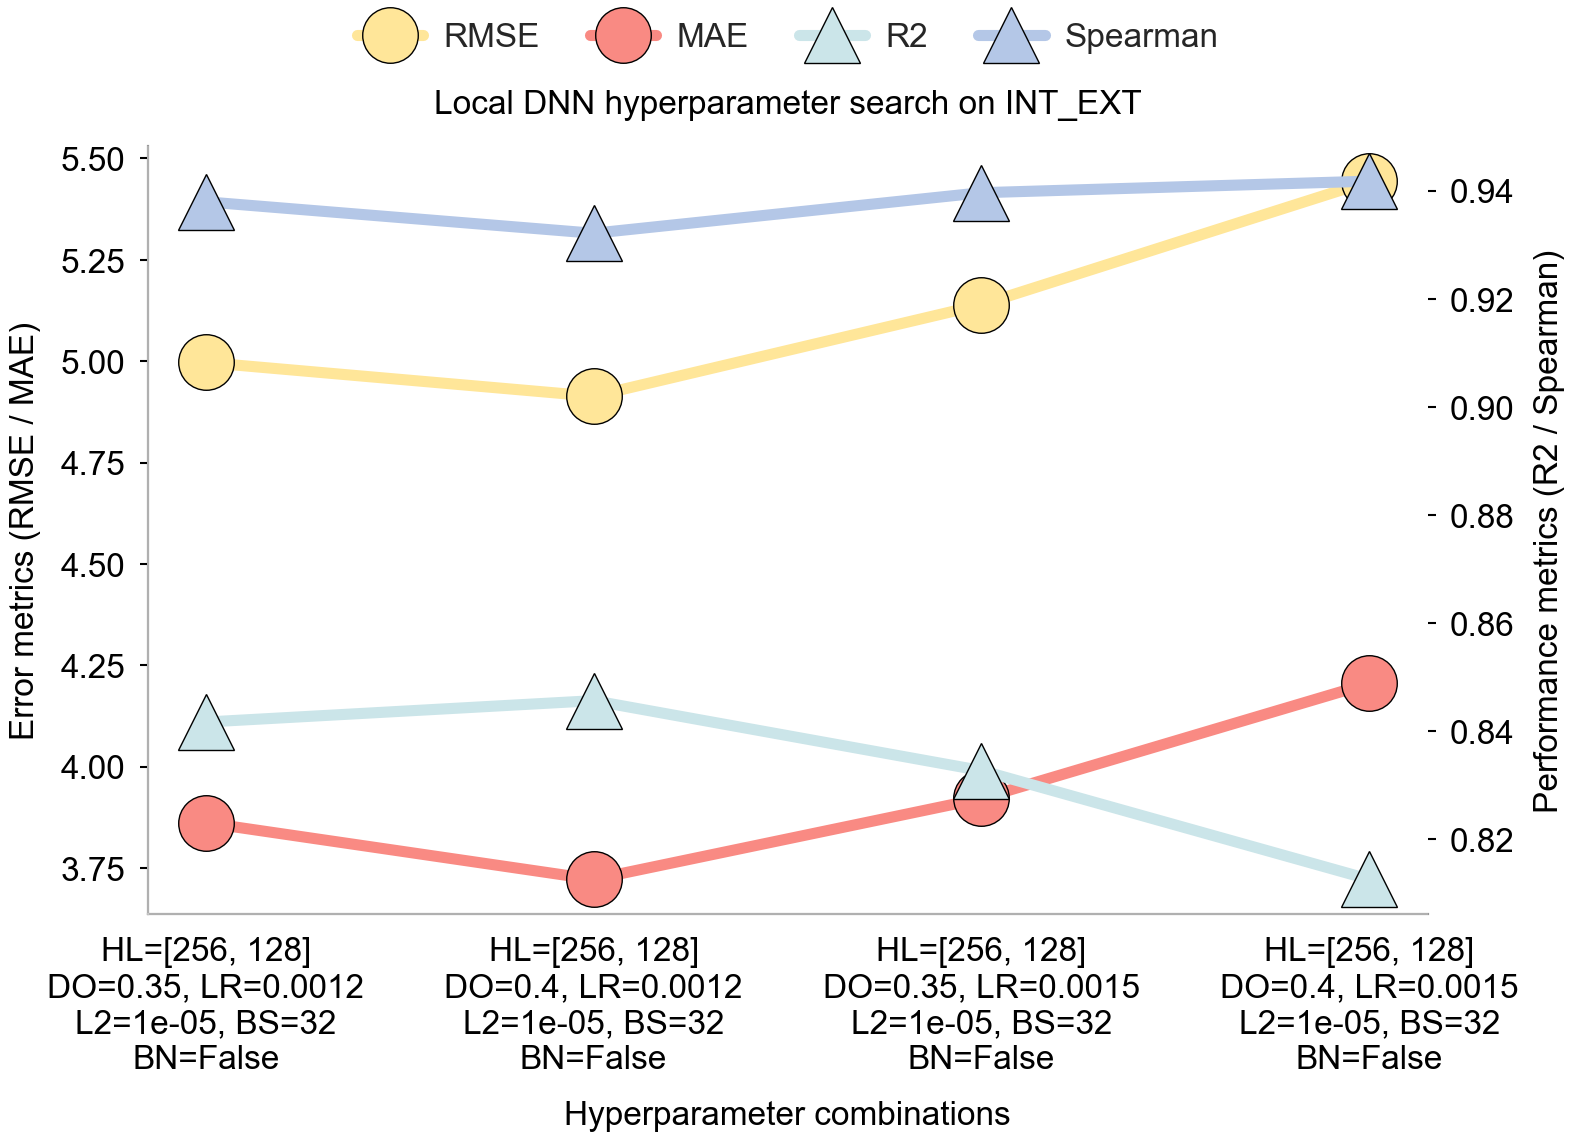

Figure saved to: ./shap_analysis\dnn_hpo_local_INT_EXT_dual_axis.svg


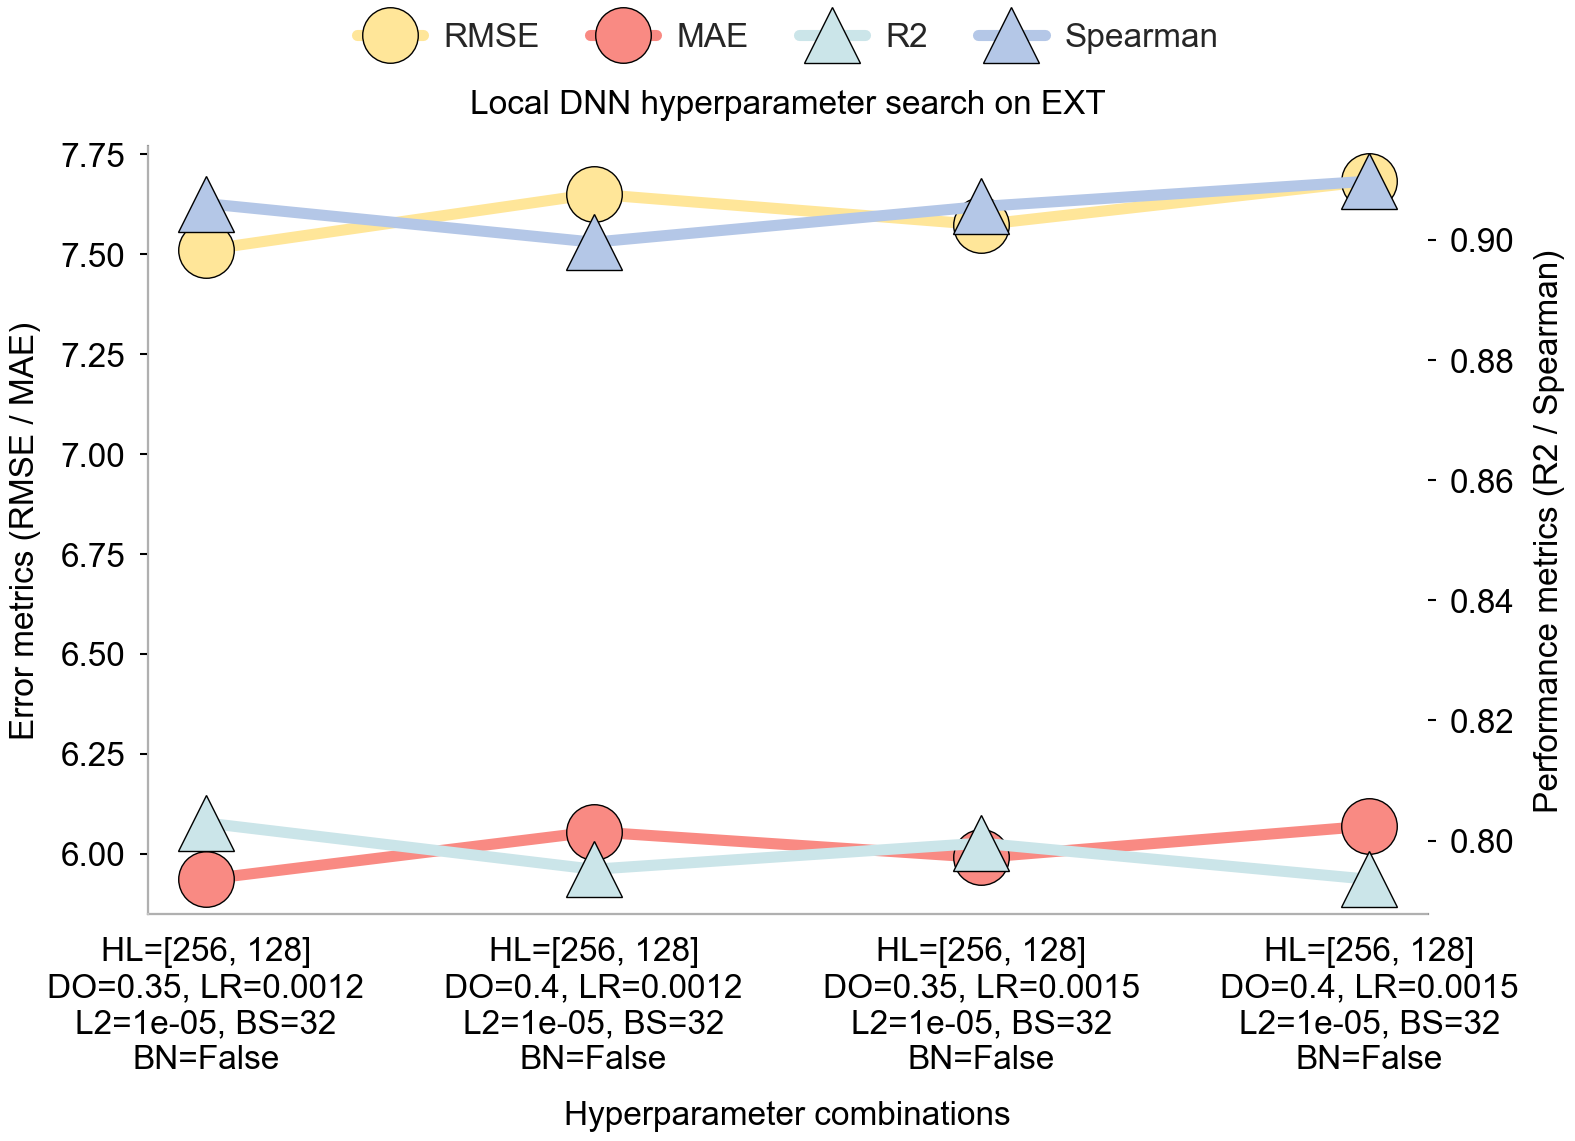

Figure saved to: ./shap_analysis\dnn_hpo_local_EXT_dual_axis.svg


In [409]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Plot local-search HPO results
# - only INT_EXT and EXT
# - full hyperparameter labels including hidden_layers
# =========================

FONT_SIZE = 24

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = FONT_SIZE
plt.rcParams["axes.titlesize"] = FONT_SIZE
plt.rcParams["axes.labelsize"] = FONT_SIZE
plt.rcParams["xtick.labelsize"] = FONT_SIZE
plt.rcParams["ytick.labelsize"] = FONT_SIZE
plt.rcParams["legend.fontsize"] = FONT_SIZE
plt.rcParams["figure.titlesize"] = FONT_SIZE

target_splits = ["INT_EXT", "EXT"]
left_metrics = ["RMSE", "MAE"]
right_metrics = ["R2", "Spearman"]

metric_colors = {
    "RMSE": "#FFE699",
    "MAE": "#F98A83",
    "R2": "#CBE5E9",
    "Spearman": "#B4C7E7"
}

left_marker = "o"
right_marker = "^"

# =========================
# Build trial-level table
# =========================
trial_rows = []
for res in all_trial_results:
    hp = res["Hyperparameters"]

    trial_label = (
        f"HL={hp['hidden_layers']}\n"
        f"DO={hp['dropout']}, LR={hp['lr']}\n"
        f"L2={hp['l2']}, BS={hp['batch_size']}\n"
        f"BN={hp['batch_norm']}"
    )

    row = {
        "Trial_ID": res["Trial_ID"],
        "Trial_Label": trial_label,
        "hidden_layers": str(hp["hidden_layers"]),
        "dropout": hp["dropout"],
        "lr": hp["lr"],
        "l2": hp["l2"],
        "batch_size": hp["batch_size"],
        "activation": hp["activation"],
        "batch_norm": hp["batch_norm"],
        "Best_Fold": res["Best_Fold"]
    }

    for split in target_splits:
        mean_metrics = res[f"Mean_{split}_Metrics"]
        for metric in left_metrics + right_metrics:
            row[f"{split}_{metric}"] = mean_metrics.get(metric, np.nan)

    trial_rows.append(row)

trial_plot_df = pd.DataFrame(trial_rows).sort_values(by="Trial_ID").reset_index(drop=True)

print("\n===== Local-search trial performance on INT_EXT and EXT =====")
print(trial_plot_df)

trial_plot_df.to_csv(
    os.path.join(SAVE_DIR, "dnn_hpo_local_int_ext_ext_plot_table.csv"),
    index=False
)


trial_lookup_df = trial_plot_df[
    ["Trial_ID", "hidden_layers", "dropout", "lr", "l2", "batch_size", "activation", "batch_norm", "Best_Fold"]
].copy()

trial_lookup_df.to_csv(
    os.path.join(SAVE_DIR, "dnn_hpo_local_trial_lookup.csv"),
    index=False
)

print("\n===== Local-search trial lookup =====")
print(trial_lookup_df)

# =========================
# Plot by split
# =========================
x = np.arange(len(trial_plot_df))
xlabels = trial_plot_df["Trial_Label"].tolist()

for split in target_splits:
    fig, ax1 = plt.subplots(figsize=(16, 16))
    ax2 = ax1.twinx()

    left_lines = []
    for metric in left_metrics:
        col = f"{split}_{metric}"
        line, = ax1.plot(
            x,
            trial_plot_df[col].values,
            color=metric_colors[metric],
            linestyle="-",
            marker=left_marker,
            markersize=40,
            linewidth=8,
            markeredgecolor="black",
            markeredgewidth=1.0,
            label=metric
        )
        left_lines.append(line)

    right_lines = []
    for metric in right_metrics:
        col = f"{split}_{metric}"
        line, = ax2.plot(
            x,
            trial_plot_df[col].values,
            color=metric_colors[metric],
            linestyle="-",
            marker=right_marker,
            markersize=40,
            linewidth=8,
            markeredgecolor="black",
            markeredgewidth=1.0,
            label=metric
        )
        right_lines.append(line)

    ax1.set_xticks(x)
    ax1.set_xticklabels(xlabels, rotation=0, ha="center")

    ax1.set_xlabel("Hyperparameter combinations", fontsize=FONT_SIZE, color="black", labelpad=18)
    ax1.set_ylabel("Error metrics (RMSE / MAE)", fontsize=FONT_SIZE, color="black", labelpad=14)
    ax2.set_ylabel("Performance metrics (R2 / Spearman)", fontsize=FONT_SIZE, color="black", labelpad=14)

    ax1.set_title(
        f"Local DNN hyperparameter search on {split}",
        fontsize=FONT_SIZE,
        color="black",
        pad=24
    )

    ax1.grid(False)
    ax2.grid(False)
    
    for side in ["left", "bottom", "top"]:
        ax1.spines[side].set_color("black")
        ax1.spines[side].set_linewidth(1.5)

    ax2.spines["right"].set_color("black")
    ax2.spines["right"].set_linewidth(1.5)

    ax1.tick_params(axis="both", colors="black", labelsize=FONT_SIZE, width=1.5, length=6, pad=10)
    ax2.tick_params(axis="y", colors="black", labelsize=FONT_SIZE, width=1.5, length=6, pad=10)

    lines = left_lines + right_lines
    labels = [line.get_label() for line in lines]
    ax1.legend(
        lines,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.20),
        ncol=4,
        frameon=False,
        fontsize=FONT_SIZE,
        handlelength=2.0,
        columnspacing=1.5,
        handletextpad=0.6
    )

    plt.subplots_adjust(
        left=0.10,
        right=0.90,
        bottom=0.34,
        top=0.82
    )

    save_path = os.path.join(SAVE_DIR, f"dnn_hpo_local_{split}_dual_axis.svg")
    plt.savefig(save_path, format="svg", bbox_inches="tight")
    plt.show()

    print(f"Figure saved to: {save_path}")

In [89]:
# ==============================================================
# Repeated 10-fold DNN ensemble
# - 10-fold x 5 repeats = 50 DNNs
# - rank by CV internal val R2
# - select top N models
# - optimize ensemble weights on INT_EXT
# - final report on EXT
# - keep artifacts for later SHAP
# ==============================================================

import os
import json
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import layers, regularizers
from sklearn.model_selection import KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import spearmanr
from scipy.optimize import minimize


# =========================
# 0) Settings
# =========================
SEED = 42
N_SPLITS = 10
N_REPEATS = 10
TOP_N = 15   # 可改为10~20
SAVE_DIR = "./repeated_10fold_dnn_ensemble"
os.makedirs(SAVE_DIR, exist_ok=True)

np.random.seed(SEED)
tf.random.set_seed(SEED)

HP = {
    "hidden_layers": [256, 128],
    "dropout": 0.30,
    "lr": 0.0012,
    "l2": 1e-5,
    "batch_size": 32,
    "activation": "relu",
    "batch_norm": False
}

EPOCHS = 200
PATIENCE_ES = 25
PATIENCE_LR = 10
MIN_LR = 1e-6
SHUFFLE_BUFFER = 4096


# =========================
# 1) Helpers
# =========================
def _to_dense_float32(x):
    if hasattr(x, "toarray"):
        x = x.toarray()
    x = np.asarray(x)
    if x.dtype != np.float32:
        x = x.astype(np.float32, copy=False)
    return x


def _safe_spearman(y_true, y_pred):
    if len(y_true) == 0:
        return float("nan")
    rho = spearmanr(y_true, y_pred)[0]
    try:
        return float(rho) if np.isfinite(rho) else float("nan")
    except Exception:
        return float("nan")


def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    if len(y_true) == 0:
        return {"RMSE": np.nan, "MAE": np.nan, "R2": np.nan, "Spearman": np.nan}

    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "R2": float(r2_score(y_true, y_pred)),
        "Spearman": _safe_spearman(y_true, y_pred)
    }


def build_preprocess_from_training_frame(X_train_df, feature_cols):
    cat_cols = [
        c for c in feature_cols
        if (X_train_df[c].dtype == "object") or (str(X_train_df[c].dtype) == "category")
    ]
    num_cols = [c for c in feature_cols if c not in cat_cols]

    preprocess = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imp", SimpleImputer(strategy="median")),
                ("sc", StandardScaler())
            ]), num_cols),
            ("cat", Pipeline([
                ("imp", SimpleImputer(strategy="most_frequent")),
                ("oh", OneHotEncoder(handle_unknown="ignore"))
            ]), cat_cols),
        ],
        remainder="drop"
    )
    return preprocess


def reset_random_seed(seed=42):
    np.random.seed(seed)
    tf.random.set_seed(seed)


def summarize_predictions(pred_matrix, weights):
    pred_matrix = np.asarray(pred_matrix, dtype=float)
    weights = np.asarray(weights, dtype=float).ravel()
    return pred_matrix @ weights


# =========================
# 2) Model
# =========================
class PlainDNN(tf.keras.Model):
    def __init__(self, input_dim, hp):
        super().__init__()
        self.hidden_blocks = []

        for units in hp["hidden_layers"]:
            block = []
            block.append(
                layers.Dense(
                    units,
                    activation=None if hp["batch_norm"] else hp["activation"],
                    kernel_regularizer=regularizers.l2(hp["l2"])
                )
            )
            if hp["batch_norm"]:
                block.append(layers.BatchNormalization())
                block.append(layers.Activation(hp["activation"]))
            if hp["dropout"] > 0:
                block.append(layers.Dropout(hp["dropout"]))
            self.hidden_blocks.append(block)

        self.out_layer = layers.Dense(1)

    def call(self, x, training=False):
        h = x
        for block in self.hidden_blocks:
            for layer in block:
                if isinstance(layer, (layers.Dropout, layers.BatchNormalization)):
                    h = layer(h, training=training)
                else:
                    h = layer(h)
        return self.out_layer(h)


def fit_one_model(X_tr, y_tr, X_va, y_va, hp, seed):
    reset_random_seed(seed)

    input_dim = X_tr.shape[1]
    model = PlainDNN(input_dim, hp)
    _ = model(tf.zeros((1, input_dim), dtype=tf.float32), training=False)

    optimizer = tf.keras.optimizers.Adam(learning_rate=hp["lr"])

    src_ds = tf.data.Dataset.from_tensor_slices((X_tr, y_tr)).shuffle(
        min(len(X_tr), SHUFFLE_BUFFER),
        seed=seed,
        reshuffle_each_iteration=True
    ).batch(hp["batch_size"], drop_remainder=False)

    val_ds = tf.data.Dataset.from_tensor_slices((X_va, y_va)).batch(
        hp["batch_size"], drop_remainder=False
    )

    best_weights = None
    best_val = np.inf
    best_epoch = 0
    patience_counter = 0
    lr_wait = 0
    current_lr = float(hp["lr"])

    for epoch in range(1, EPOCHS + 1):
        for xb, yb in src_ds:
            with tf.GradientTape() as tape:
                pred = model(xb, training=True)
                pred = tf.reshape(pred, [-1])
                yb = tf.cast(tf.reshape(yb, [-1]), tf.float32)

                mse = tf.reduce_mean(tf.square(yb - pred))
                reg_loss = tf.add_n(model.losses) if len(model.losses) > 0 else tf.constant(0.0, dtype=tf.float32)
                loss = mse + reg_loss

            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))

        val_losses = []
        for xb_val, yb_val in val_ds:
            pred_val = model(xb_val, training=False)
            pred_val = tf.reshape(pred_val, [-1])
            yb_val = tf.cast(tf.reshape(yb_val, [-1]), tf.float32)
            val_mse = tf.reduce_mean(tf.square(yb_val - pred_val))
            val_losses.append(float(val_mse.numpy()))
        mean_val = float(np.mean(val_losses))

        if mean_val < best_val:
            best_val = mean_val
            best_epoch = epoch
            best_weights = model.get_weights()
            patience_counter = 0
            lr_wait = 0
        else:
            patience_counter += 1
            lr_wait += 1

        if lr_wait >= PATIENCE_LR:
            current_lr = max(current_lr * 0.5, MIN_LR)
            optimizer.learning_rate.assign(current_lr)
            lr_wait = 0

        if patience_counter >= PATIENCE_ES:
            break

    if best_weights is not None:
        model.set_weights(best_weights)

    return model, best_epoch


def predict_model(model, X):
    if X.shape[0] == 0:
        return np.array([], dtype=float)
    return model(X, training=False).numpy().ravel()


# =========================
# 3) Train repeated CV models
# =========================
all_models_info = []
model_counter = 0

for rep in range(N_REPEATS):
    print("\n" + "=" * 100)
    print(f"REPEAT {rep + 1}/{N_REPEATS}")
    print("=" * 100)

    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED + rep)

    for fold_id, (tr_idx, va_idx) in enumerate(kf.split(X_train_raw), start=1):
        model_counter += 1
        print(f"\nModel {model_counter} | Repeat {rep + 1}, Fold {fold_id}/{N_SPLITS}")

        X_tr_raw = X_train_raw.iloc[tr_idx].copy()
        X_va_raw = X_train_raw.iloc[va_idx].copy()

        y_tr = np.asarray(y_train)[tr_idx]
        y_va = np.asarray(y_train)[va_idx]

        preprocess = build_preprocess_from_training_frame(X_tr_raw, feature_cols)

        X_tr = preprocess.fit_transform(X_tr_raw)
        X_va = preprocess.transform(X_va_raw)

        X_int_ext_fold = preprocess.transform(X_int_ext_raw)
        X_ext_fold = preprocess.transform(X_ext_raw)

        X_tr = _to_dense_float32(X_tr)
        X_va = _to_dense_float32(X_va)
        X_int_ext_fold = _to_dense_float32(X_int_ext_fold)
        X_ext_fold = _to_dense_float32(X_ext_fold)

        seed_this = SEED * 1000 + rep * 100 + fold_id
        model, best_epoch = fit_one_model(X_tr, y_tr, X_va, y_va, HP, seed_this)

        pred_va = predict_model(model, X_va)
        pred_int_ext = predict_model(model, X_int_ext_fold)
        pred_ext = predict_model(model, X_ext_fold)

        val_metrics = compute_metrics(y_va, pred_va)
        int_ext_metrics = compute_metrics(y_int_ext, pred_int_ext)
        ext_metrics = compute_metrics(y_ext, pred_ext)

        print(
            f"CV-Val R2={val_metrics['R2']:.4f} | "
            f"AGE2 R2={int_ext_metrics['R2']:.4f} | "
            f"EXT R2={ext_metrics['R2']:.4f} | "
            f"BestEpoch={best_epoch}"
        )

        all_models_info.append({
            "model_id": model_counter,
            "repeat": rep + 1,
            "fold": fold_id,
            "seed": seed_this,
            "best_epoch": best_epoch,
            "cv_val_metrics": val_metrics,
            "int_ext_metrics": int_ext_metrics,
            "ext_metrics": ext_metrics,
            "pred_int_ext": pred_int_ext,
            "pred_ext": pred_ext,
            "model": model,
            "preprocess": preprocess,
            "hyperparameters": HP
        })


# =========================
# 4) Rank by CV-Val and select top N
# =========================
ranking_df = pd.DataFrame([
    {
        "model_id": m["model_id"],
        "repeat": m["repeat"],
        "fold": m["fold"],
        "seed": m["seed"],
        "best_epoch": m["best_epoch"],
        "CV_Val_RMSE": m["cv_val_metrics"]["RMSE"],
        "CV_Val_MAE": m["cv_val_metrics"]["MAE"],
        "CV_Val_R2": m["cv_val_metrics"]["R2"],
        "CV_Val_Spearman": m["cv_val_metrics"]["Spearman"],
        "AGE2_RMSE": m["int_ext_metrics"]["RMSE"],
        "AGE2_MAE": m["int_ext_metrics"]["MAE"],
        "AGE2_R2": m["int_ext_metrics"]["R2"],
        "AGE2_Spearman": m["int_ext_metrics"]["Spearman"],
        "EXT_RMSE": m["ext_metrics"]["RMSE"],
        "EXT_MAE": m["ext_metrics"]["MAE"],
        "EXT_R2": m["ext_metrics"]["R2"],
        "EXT_Spearman": m["ext_metrics"]["Spearman"],
    }
    for m in all_models_info
]).sort_values(
    by=["CV_Val_R2", "CV_Val_Spearman"],
    ascending=False
).reset_index(drop=True)

top_n = min(TOP_N, len(all_models_info))
top_model_ids = ranking_df.head(top_n)["model_id"].tolist()
selected_models = [m for m in all_models_info if m["model_id"] in top_model_ids]

print("\n" + "=" * 100)
print(f"Selected top {top_n} models by CV internal validation R2")
print("=" * 100)
print(ranking_df.head(top_n))


# =========================
# 5) Optimize weights on INT_EXT
# =========================
pred_matrix_int_ext = np.column_stack([m["pred_int_ext"] for m in selected_models])
pred_matrix_ext = np.column_stack([m["pred_ext"] for m in selected_models])

y_int_ext_true = np.asarray(y_int_ext, dtype=float)
y_ext_true = np.asarray(y_ext, dtype=float)

def objective_rmse(weights):
    pred = pred_matrix_int_ext @ weights
    return np.sqrt(mean_squared_error(y_int_ext_true, pred))

M = pred_matrix_int_ext.shape[1]
init_w = np.ones(M, dtype=float) / M
bounds = [(0.0, 1.0)] * M
constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}]

res = minimize(
    objective_rmse,
    init_w,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

if res.success and res.x is not None and np.isfinite(res.x).all():
    best_w = np.asarray(res.x, dtype=float)
    best_w = best_w / best_w.sum() if best_w.sum() > 0 else np.ones(M) / M
else:
    print("WARNING: optimization failed, fallback to uniform weights")
    best_w = np.ones(M, dtype=float) / M

selected_model_labels = [
    f"Model{m['model_id']}_R{m['repeat']}_F{m['fold']}" for m in selected_models
]
best_weights = dict(zip(selected_model_labels, best_w))

ensemble_pred_int_ext = summarize_predictions(pred_matrix_int_ext, best_w)
ensemble_pred_ext = summarize_predictions(pred_matrix_ext, best_w)

ensemble_int_ext_metrics = compute_metrics(y_int_ext_true, ensemble_pred_int_ext)
ensemble_ext_metrics = compute_metrics(y_ext_true, ensemble_pred_ext)

print("\n" + "=" * 100)
print("ENSEMBLE RESULTS")
print("=" * 100)
print("Optimized on: INT_EXT")
print("\nWeights:")
for k, v in sorted(best_weights.items(), key=lambda x: x[1], reverse=True):
    print(f"{k}: {v:.6f}")

print("\nINT_EXT:", {k: round(v, 4) if np.isfinite(v) else np.nan for k, v in ensemble_int_ext_metrics.items()})
print("EXT    :", {k: round(v, 4) if np.isfinite(v) else np.nan for k, v in ensemble_ext_metrics.items()})


# =========================
# 6) Save artifacts
# =========================
artifact = {
    "strategy": "Repeated10Fold_DNN_SelectByCV_WeightOnINTEXT",
    "n_splits": N_SPLITS,
    "n_repeats": N_REPEATS,
    "top_n": top_n,
    "hyperparameters": HP,

    "ranking_df": ranking_df,
    "selected_model_ids": top_model_ids,
    "selected_models": selected_models,

    "weights": best_weights,
    "weight_vector": best_w,

    "ensemble_pred_int_ext": ensemble_pred_int_ext,
    "ensemble_pred_ext": ensemble_pred_ext,

    "ensemble_int_ext_metrics": ensemble_int_ext_metrics,
    "ensemble_ext_metrics": ensemble_ext_metrics
}

ranking_df.to_csv(os.path.join(SAVE_DIR, "repeated10fold_model_ranking.csv"), index=False)

with open(os.path.join(SAVE_DIR, "repeated10fold_dnn_ensemble_artifact.pkl"), "wb") as f:
    pickle.dump(artifact, f)

with open(os.path.join(SAVE_DIR, "repeated10fold_dnn_ensemble_summary.json"), "w", encoding="utf-8") as f:
    json.dump({
        "strategy": artifact["strategy"],
        "n_splits": artifact["n_splits"],
        "n_repeats": artifact["n_repeats"],
        "top_n": artifact["top_n"],
        "hyperparameters": artifact["hyperparameters"],
        "ensemble_int_ext_metrics": artifact["ensemble_int_ext_metrics"],
        "ensemble_ext_metrics": artifact["ensemble_ext_metrics"],
        "weights": artifact["weights"]
    }, f, ensure_ascii=False, indent=2)

print(f"\nSaved to: {SAVE_DIR}")

if "model_results" not in globals():
    model_results = {}

model_results["Repeated10Fold_DNN_Ensemble"] = {
    "Optimized_on": "INT_EXT",
    "Selected_by": "CV internal val R2",
    "Top_N": top_n,
    "Weights": best_weights,
    "INT_EXT_pred": ensemble_pred_int_ext,
    "EXT_pred": ensemble_pred_ext,
    "INT_EXT": ensemble_int_ext_metrics,
    "EXT": ensemble_ext_metrics
}

print("Added to model_results['Repeated10Fold_DNN_Ensemble']")


REPEAT 1/10

Model 1 | Repeat 1, Fold 1/10
CV-Val R2=0.9294 | AGE2 R2=0.8307 | EXT R2=0.8121 | BestEpoch=136

Model 2 | Repeat 1, Fold 2/10
CV-Val R2=0.9433 | AGE2 R2=0.8507 | EXT R2=0.7991 | BestEpoch=200

Model 3 | Repeat 1, Fold 3/10
CV-Val R2=0.9227 | AGE2 R2=0.8495 | EXT R2=0.8098 | BestEpoch=149

Model 4 | Repeat 1, Fold 4/10
CV-Val R2=0.9493 | AGE2 R2=0.8536 | EXT R2=0.7947 | BestEpoch=156

Model 5 | Repeat 1, Fold 5/10
CV-Val R2=0.9266 | AGE2 R2=0.8041 | EXT R2=0.7848 | BestEpoch=158

Model 6 | Repeat 1, Fold 6/10
CV-Val R2=0.9400 | AGE2 R2=0.8402 | EXT R2=0.8192 | BestEpoch=166

Model 7 | Repeat 1, Fold 7/10
CV-Val R2=0.9402 | AGE2 R2=0.8292 | EXT R2=0.7934 | BestEpoch=147

Model 8 | Repeat 1, Fold 8/10
CV-Val R2=0.8573 | AGE2 R2=0.8347 | EXT R2=0.7940 | BestEpoch=166

Model 9 | Repeat 1, Fold 9/10
CV-Val R2=0.8424 | AGE2 R2=0.8630 | EXT R2=0.7845 | BestEpoch=37

Model 10 | Repeat 1, Fold 10/10
CV-Val R2=0.9435 | AGE2 R2=0.8359 | EXT R2=0.7940 | BestEpoch=171

REPEAT 2/10

Mo

In [91]:
# ==============================================================
# Save repeated DNN ensemble for future reuse
# ==============================================================

import os
import json
import pickle
import numpy as np

ENSEMBLE_SAVE_DIR = "./saved_repeated_dnn_ensemble"
os.makedirs(ENSEMBLE_SAVE_DIR, exist_ok=True)

saved_model_info = []

for i, m in enumerate(selected_models):
    model_label = f"model_{i+1:02d}_id{m['model_id']}_r{m['repeat']}_f{m['fold']}"
    model_dir = os.path.join(ENSEMBLE_SAVE_DIR, model_label)
    os.makedirs(model_dir, exist_ok=True)


    keras_model_path = os.path.join(model_dir, "keras_model.keras")
    m["model"].save(keras_model_path)


    preprocess_path = os.path.join(model_dir, "preprocess.pkl")
    with open(preprocess_path, "wb") as f:
        pickle.dump(m["preprocess"], f)


    meta = {
        "model_id": int(m["model_id"]),
        "repeat": int(m["repeat"]),
        "fold": int(m["fold"]),
        "seed": int(m["seed"]),
        "best_epoch": int(m["best_epoch"]),
        "hyperparameters": m["hyperparameters"],
        "cv_val_metrics": m["cv_val_metrics"],
        "int_ext_metrics": m["int_ext_metrics"],
        "ext_metrics": m["ext_metrics"],
    }
    with open(os.path.join(model_dir, "meta.json"), "w", encoding="utf-8") as f:
        json.dump(meta, f, ensure_ascii=False, indent=2)

    saved_model_info.append({
        "label": model_label,
        "model_path": keras_model_path,
        "preprocess_path": preprocess_path,
        "meta_path": os.path.join(model_dir, "meta.json")
    })


ensemble_config = {
    "strategy": "Repeated10Fold_DNN_SelectByCV_WeightOnINTEXT",
    "n_splits": int(N_SPLITS),
    "n_repeats": int(N_REPEATS),
    "top_n": int(top_n),
    "hyperparameters": HP,
    "selected_model_labels": [x["label"] for x in saved_model_info],
    "weight_vector": [float(x) for x in best_w],
    "weights": {k: float(v) for k, v in best_weights.items()},
    "feature_cols": list(feature_cols),
    "ensemble_int_ext_metrics": ensemble_int_ext_metrics,
    "ensemble_ext_metrics": ensemble_ext_metrics
}

with open(os.path.join(ENSEMBLE_SAVE_DIR, "ensemble_config.json"), "w", encoding="utf-8") as f:
    json.dump(ensemble_config, f, ensure_ascii=False, indent=2)

with open(os.path.join(ENSEMBLE_SAVE_DIR, "saved_model_index.pkl"), "wb") as f:
    pickle.dump(saved_model_info, f)

print(f"Ensemble saved to: {ENSEMBLE_SAVE_DIR}")

Ensemble saved to: ./saved_repeated_dnn_ensemble
